In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
train_data=pd.read_excel(r'Data\Data_Train.xlsx')

In [4]:
test_data=pd.read_excel(r"Data\Test_set.xlsx")

In [5]:
pd.set_option('Display.max_columns',None)

In [6]:
train_data

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


In [7]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          10683 non-null  str  
 1   Date_of_Journey  10683 non-null  str  
 2   Source           10683 non-null  str  
 3   Destination      10683 non-null  str  
 4   Route            10682 non-null  str  
 5   Dep_Time         10683 non-null  str  
 6   Arrival_Time     10683 non-null  str  
 7   Duration         10683 non-null  str  
 8   Total_Stops      10682 non-null  str  
 9   Additional_Info  10683 non-null  str  
 10  Price            10683 non-null  int64
dtypes: int64(1), str(10)
memory usage: 918.2 KB


In [8]:
test_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2671 entries, 0 to 2670
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Airline          2671 non-null   str  
 1   Date_of_Journey  2671 non-null   str  
 2   Source           2671 non-null   str  
 3   Destination      2671 non-null   str  
 4   Route            2671 non-null   str  
 5   Dep_Time         2671 non-null   str  
 6   Arrival_Time     2671 non-null   str  
 7   Duration         2671 non-null   str  
 8   Total_Stops      2671 non-null   str  
 9   Additional_Info  2671 non-null   str  
dtypes: str(10)
memory usage: 208.8 KB


In [9]:
train_data.duplicated().sum()

np.int64(220)

In [10]:
test_data.duplicated().sum()

np.int64(26)

### both the trains and test data have duplicated  records in them but it is not possible in this case so do not remove it

## Missing Values

In [11]:
train_data.isnull().sum()# only 1 missing value in Route and Total_stops in train data

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [12]:
test_data.isnull().sum()## no null values

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
dtype: int64

### Removing the null values from training data

In [13]:
train_data.dropna(inplace=True)

In [14]:
print(train_data.isnull().sum())
print("*"*25)
print(test_data.isnull().sum())
# train and test data have 0 missing value

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64
*************************
Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
dtype: int64


In [15]:
print(train_data.shape)

(10682, 11)


### EDA and Data Cleaning

# 1. Data of journey

## Not extracting the year since the data is from 2019 only

In [16]:
print(train_data.columns)

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='str')


In [17]:
train_data

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


In [18]:
## Convert Date_of_Journey to dataset
train_data['Date_of_Journey']=pd.to_datetime(train_data['Date_of_Journey'], format='%d/%m/%Y')
test_data['Date_of_Journey']=pd.to_datetime(test_data['Date_of_Journey'], format= '%d/%m/%Y')

# Extract day and month from date_of_journey
train_data['Journey_Day']= train_data['Date_of_Journey'].dt.day
train_data['Journey_Month']= train_data['Date_of_Journey'].dt.month

test_data['Journey_Day']=test_data['Date_of_Journey'].dt.day
test_data['Journey_Month']=test_data['Date_of_Journey'].dt.month

## Drop date_of_journey as it is now redundant
train_data.drop(['Date_of_Journey'],axis=1, inplace=True)
test_data.drop(['Date_of_Journey'],axis=1,inplace=True)


In [19]:
train_data

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107,9,4
10679,Air India,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145,27,4
10680,Jet Airways,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229,27,4
10681,Vistara,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648,1,3


# 2. Departure Time and 3. Arrival Time

In [20]:
train_data['Dep_Time']= pd.to_datetime(train_data['Dep_Time'])
train_data['Arrival_Time']= pd.to_datetime(train_data['Arrival_Time'])

test_data['Dep_Time']= pd.to_datetime(test_data['Dep_Time'])
test_data['Arrival_Time']= pd.to_datetime(test_data['Arrival_Time'])

In [21]:
train_data

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month
0,IndiGo,Banglore,New Delhi,BLR → DEL,2026-07-18 22:20:00,2026-03-22 01:10:00,2h 50m,non-stop,No info,3897,24,3
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2026-07-18 05:50:00,2026-07-18 13:15:00,7h 25m,2 stops,No info,7662,1,5
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2026-07-18 09:25:00,2026-06-10 04:25:00,19h,2 stops,No info,13882,9,6
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,2026-07-18 18:05:00,2026-07-18 23:30:00,5h 25m,1 stop,No info,6218,12,5
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,2026-07-18 16:50:00,2026-07-18 21:35:00,4h 45m,1 stop,No info,13302,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,2026-07-18 19:55:00,2026-07-18 22:25:00,2h 30m,non-stop,No info,4107,9,4
10679,Air India,Kolkata,Banglore,CCU → BLR,2026-07-18 20:45:00,2026-07-18 23:20:00,2h 35m,non-stop,No info,4145,27,4
10680,Jet Airways,Banglore,Delhi,BLR → DEL,2026-07-18 08:20:00,2026-07-18 11:20:00,3h,non-stop,No info,7229,27,4
10681,Vistara,Banglore,New Delhi,BLR → DEL,2026-07-18 11:30:00,2026-07-18 14:10:00,2h 40m,non-stop,No info,12648,1,3


In [22]:
# Extract hour and minute from Dep_Time and Arrival_Time
train_data['Dep_Hour']= train_data['Dep_Time'].dt.hour
train_data['Dep_Minute']= train_data['Dep_Time'].dt.minute

train_data['Arrival_Hour']= train_data['Arrival_Time'].dt.hour
train_data['Arrival_Minute']= train_data['Arrival_Time'].dt.minute

test_data['Dep_Hour']= test_data['Dep_Time'].dt.hour
test_data['Dep_Minute']= test_data['Dep_Time'].dt.minute

test_data['Arrival_Hour']= test_data['Arrival_Time'].dt.hour
test_data['Arrival_Minute']= test_data['Arrival_Time'].dt.minute

# Drop Dep_time and Arrival_Time as they are now redundant
train_data.drop(['Dep_Time','Arrival_Time'],axis=1, inplace=True)
test_data.drop(['Dep_Time','Arrival_Time'],axis=1,inplace=True)



In [23]:
train_data

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,22,20,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,5,50,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2 stops,No info,13882,9,6,9,25,4,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1 stop,No info,6218,12,5,18,5,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1 stop,No info,13302,1,3,16,50,21,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,2h 30m,non-stop,No info,4107,9,4,19,55,22,25
10679,Air India,Kolkata,Banglore,CCU → BLR,2h 35m,non-stop,No info,4145,27,4,20,45,23,20
10680,Jet Airways,Banglore,Delhi,BLR → DEL,3h,non-stop,No info,7229,27,4,8,20,11,20
10681,Vistara,Banglore,New Delhi,BLR → DEL,2h 40m,non-stop,No info,12648,1,3,11,30,14,10


# 4.Duration

In [24]:
### Handling Duration feature
def convert_duration(duration):
    duration=duration.split()
    hours=0
    minutes=0
    for d in duration:
        if 'h' in d:
            hours=int(d[:-1])
        elif 'm' in d:
            minutes = int(d[:-1])
    return hours * 60 + minutes

train_data['Duration']= train_data['Duration'].apply(convert_duration)
test_data['Duration']=test_data['Duration'].apply(convert_duration)

In [25]:
train_data

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,170,non-stop,No info,3897,24,3,22,20,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,445,2 stops,No info,7662,1,5,5,50,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,1140,2 stops,No info,13882,9,6,9,25,4,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,325,1 stop,No info,6218,12,5,18,5,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,285,1 stop,No info,13302,1,3,16,50,21,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,150,non-stop,No info,4107,9,4,19,55,22,25
10679,Air India,Kolkata,Banglore,CCU → BLR,155,non-stop,No info,4145,27,4,20,45,23,20
10680,Jet Airways,Banglore,Delhi,BLR → DEL,180,non-stop,No info,7229,27,4,8,20,11,20
10681,Vistara,Banglore,New Delhi,BLR → DEL,160,non-stop,No info,12648,1,3,11,30,14,10


In [26]:
print(train_data.columns)

Index(['Airline', 'Source', 'Destination', 'Route', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price', 'Journey_Day', 'Journey_Month', 'Dep_Hour',
       'Dep_Minute', 'Arrival_Hour', 'Arrival_Minute'],
      dtype='str')


In [27]:
train_data.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,170,non-stop,No info,3897,24,3,22,20,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,445,2 stops,No info,7662,1,5,5,50,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,1140,2 stops,No info,13882,9,6,9,25,4,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,325,1 stop,No info,6218,12,5,18,5,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,285,1 stop,No info,13302,1,3,16,50,21,35


### 5. Creating a new feature "Journey Day" (monday=0,tuesday=1,..........sunday=6)

In [28]:
## Journey Day of week
train_data['Journey_Day_of_Week']=train_data.apply(lambda row: pd.Timestamp(year=2019, month=row['Journey_Month'],
day=row['Journey_Day']).dayofweek,axis=1)

test_data['Journey_Day_of_Week']=test_data.apply(lambda row: pd.Timestamp(year=2019, month=row['Journey_Month'],
day=row['Journey_Day']).dayofweek,axis=1)


### 6. Creating a new feature - whether the day of journey was weekend or not


In [29]:
# Is weekend
train_data['Is_Weekend']=train_data['Journey_Day_of_Week'].apply(lambda x:1 if x>=5 else 0)
test_data['IS_Weekend']= test_data['Journey_Day_of_Week'].apply(lambda x: 1 if x>=5 else 0)

In [30]:
train_data

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute,Journey_Day_of_Week,Is_Weekend
0,IndiGo,Banglore,New Delhi,BLR → DEL,170,non-stop,No info,3897,24,3,22,20,1,10,6,1
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,445,2 stops,No info,7662,1,5,5,50,13,15,2,0
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,1140,2 stops,No info,13882,9,6,9,25,4,25,6,1
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,325,1 stop,No info,6218,12,5,18,5,23,30,6,1
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,285,1 stop,No info,13302,1,3,16,50,21,35,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,150,non-stop,No info,4107,9,4,19,55,22,25,1,0
10679,Air India,Kolkata,Banglore,CCU → BLR,155,non-stop,No info,4145,27,4,20,45,23,20,5,1
10680,Jet Airways,Banglore,Delhi,BLR → DEL,180,non-stop,No info,7229,27,4,8,20,11,20,5,1
10681,Vistara,Banglore,New Delhi,BLR → DEL,160,non-stop,No info,12648,1,3,11,30,14,10,4,0


### 7. creating a new feature Departure part of the day - morning , afternoon , evening, night

In [31]:
def part_of_day(hour):
    if 5 <=hour < 12:
        return 'Morning'
    elif 12<=hour <17:
        return 'Afternoon'
    elif 17 <=hour <21:
        return 'Evening'
    else:
        return 'Night'

In [32]:
# Departure part of the day
train_data['Dep_Part_of_Day']= train_data['Dep_Hour'].apply(part_of_day)
test_data['Dep_Part_of_Day']= test_data['Dep_Hour'].apply(part_of_day)

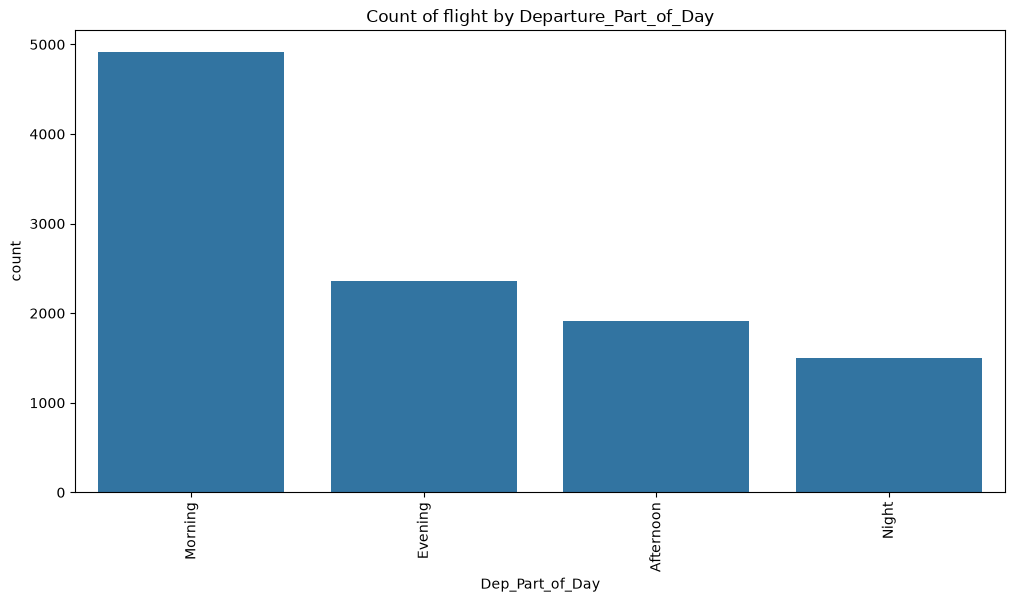

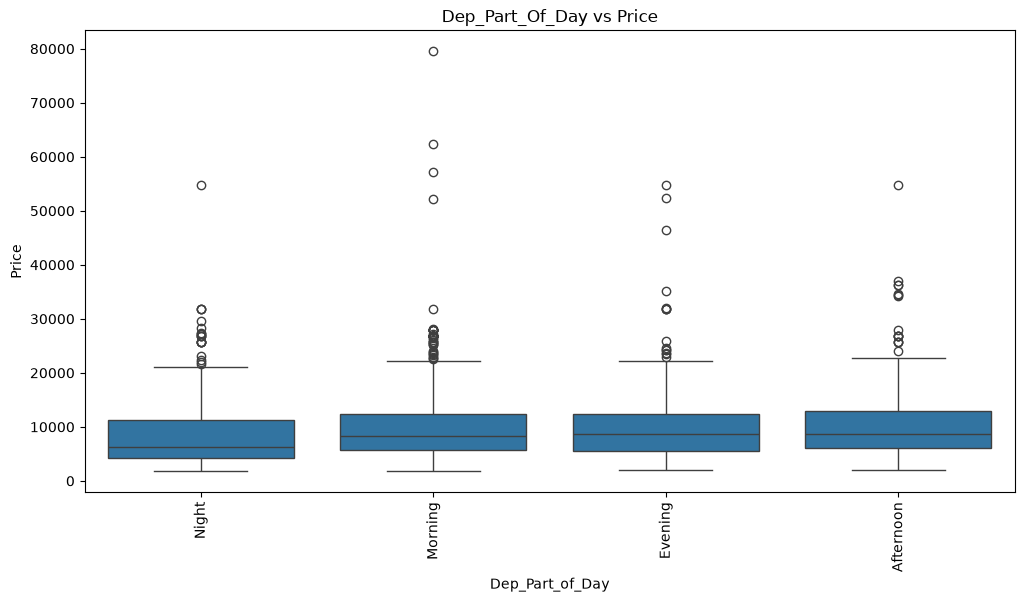

In [33]:
# Dep_Part_of_Day feature distribution
plt.figure(figsize=(12,6))
sns.countplot(data= train_data,x='Dep_Part_of_Day', order= train_data['Dep_Part_of_Day'].value_counts().index)
plt.title('Count of flight by Departure_Part_of_Day')
plt.xticks(rotation=90)
plt.show()

# Dep_Part_of_Day feature dependence on Price
plt.figure(figsize=(12,6))
sns.boxplot(data=train_data, x='Dep_Part_of_Day',y ='Price',
order= train_data.groupby('Dep_Part_of_Day')['Price'].median().sort_values().index)
plt.title('Dep_Part_Of_Day vs Price')
plt.xticks(rotation=90)
plt.show()


# 8. Number Of routes

In [34]:
train_data['Num_Routes'] = train_data['Route'].apply(lambda x: len(x.split('→')))
test_data['Num_Routes'] = test_data['Route'].apply(lambda x: len(x.split('→')))

In [35]:
train_data

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute,Journey_Day_of_Week,Is_Weekend,Dep_Part_of_Day,Num_Routes
0,IndiGo,Banglore,New Delhi,BLR → DEL,170,non-stop,No info,3897,24,3,22,20,1,10,6,1,Night,2
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,445,2 stops,No info,7662,1,5,5,50,13,15,2,0,Morning,4
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,1140,2 stops,No info,13882,9,6,9,25,4,25,6,1,Morning,4
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,325,1 stop,No info,6218,12,5,18,5,23,30,6,1,Evening,3
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,285,1 stop,No info,13302,1,3,16,50,21,35,4,0,Afternoon,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,150,non-stop,No info,4107,9,4,19,55,22,25,1,0,Evening,2
10679,Air India,Kolkata,Banglore,CCU → BLR,155,non-stop,No info,4145,27,4,20,45,23,20,5,1,Evening,2
10680,Jet Airways,Banglore,Delhi,BLR → DEL,180,non-stop,No info,7229,27,4,8,20,11,20,5,1,Morning,2
10681,Vistara,Banglore,New Delhi,BLR → DEL,160,non-stop,No info,12648,1,3,11,30,14,10,4,0,Morning,2


# 9. Arrival Part of the day

In [36]:
# Arrival part of the day
train_data['Arrival_Part_Of_Day']=train_data['Arrival_Hour'].apply(part_of_day)
test_data['Arrival_Part_Of_Day']=test_data['Arrival_Hour'].apply(part_of_day)


In [37]:
train_data.columns

Index(['Airline', 'Source', 'Destination', 'Route', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price', 'Journey_Day', 'Journey_Month', 'Dep_Hour',
       'Dep_Minute', 'Arrival_Hour', 'Arrival_Minute', 'Journey_Day_of_Week',
       'Is_Weekend', 'Dep_Part_of_Day', 'Num_Routes', 'Arrival_Part_Of_Day'],
      dtype='str')

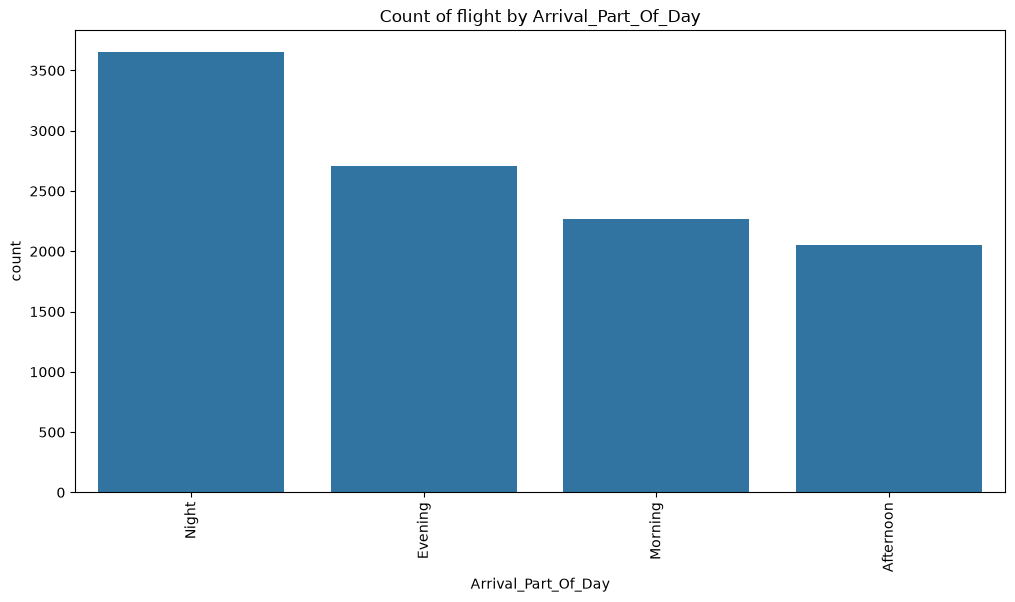

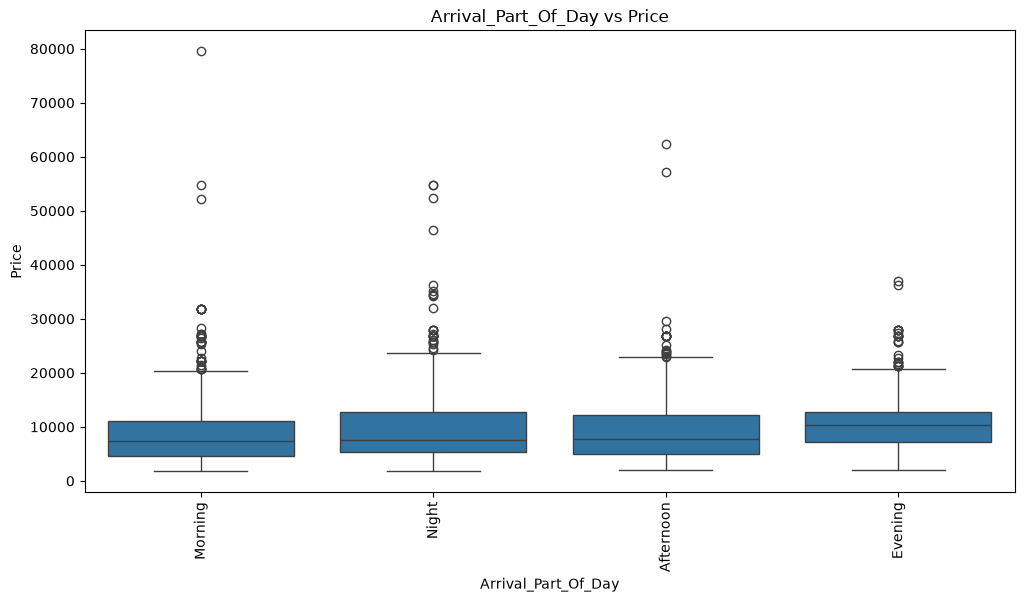

In [38]:
# Arrival_Part_of_Day feature Distribution
plt.figure(figsize=(12,6))
sns.countplot(data= train_data,x='Arrival_Part_Of_Day', order= train_data['Arrival_Part_Of_Day'].value_counts().index)
plt.title('Count of flight by Arrival_Part_Of_Day')
plt.xticks(rotation=90)
plt.show()

#Arrival_Part_of_Day feature dependance on Price
plt.figure(figsize=(12,6))
sns.boxplot(data=train_data, x='Arrival_Part_Of_Day',y ='Price',
order= train_data.groupby('Arrival_Part_Of_Day')['Price'].median().sort_values().index)
plt.title('Arrival_Part_Of_Day vs Price')
plt.xticks(rotation=90)
plt.show()


# 10. Flight Duration in hours

In [39]:
# Flight Duration in hours
train_data['Duration_Hours']=train_data['Duration']/60
test_data['Duration_Hours']= test_data['Duration']/60

In [40]:
train_data

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute,Journey_Day_of_Week,Is_Weekend,Dep_Part_of_Day,Num_Routes,Arrival_Part_Of_Day,Duration_Hours
0,IndiGo,Banglore,New Delhi,BLR → DEL,170,non-stop,No info,3897,24,3,22,20,1,10,6,1,Night,2,Night,2.833333
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,445,2 stops,No info,7662,1,5,5,50,13,15,2,0,Morning,4,Afternoon,7.416667
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,1140,2 stops,No info,13882,9,6,9,25,4,25,6,1,Morning,4,Night,19.000000
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,325,1 stop,No info,6218,12,5,18,5,23,30,6,1,Evening,3,Night,5.416667
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,285,1 stop,No info,13302,1,3,16,50,21,35,4,0,Afternoon,3,Night,4.750000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,150,non-stop,No info,4107,9,4,19,55,22,25,1,0,Evening,2,Night,2.500000
10679,Air India,Kolkata,Banglore,CCU → BLR,155,non-stop,No info,4145,27,4,20,45,23,20,5,1,Evening,2,Night,2.583333
10680,Jet Airways,Banglore,Delhi,BLR → DEL,180,non-stop,No info,7229,27,4,8,20,11,20,5,1,Morning,2,Morning,3.000000
10681,Vistara,Banglore,New Delhi,BLR → DEL,160,non-stop,No info,12648,1,3,11,30,14,10,4,0,Morning,2,Afternoon,2.666667


## Dropping Unnecessary features now

In [41]:
train_data.drop(['Route', 'Duration', 'Dep_Hour', 'Dep_Minute', 'Arrival_Hour', 'Arrival_Minute'],axis=1,inplace=True)
test_data.drop(['Route', 'Duration', 'Dep_Hour', 'Dep_Minute', 'Arrival_Hour', 'Arrival_Minute'],axis=1,inplace=True)

In [42]:
train_data

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Journey_Day_of_Week,Is_Weekend,Dep_Part_of_Day,Num_Routes,Arrival_Part_Of_Day,Duration_Hours
0,IndiGo,Banglore,New Delhi,non-stop,No info,3897,24,3,6,1,Night,2,Night,2.833333
1,Air India,Kolkata,Banglore,2 stops,No info,7662,1,5,2,0,Morning,4,Afternoon,7.416667
2,Jet Airways,Delhi,Cochin,2 stops,No info,13882,9,6,6,1,Morning,4,Night,19.000000
3,IndiGo,Kolkata,Banglore,1 stop,No info,6218,12,5,6,1,Evening,3,Night,5.416667
4,IndiGo,Banglore,New Delhi,1 stop,No info,13302,1,3,4,0,Afternoon,3,Night,4.750000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,non-stop,No info,4107,9,4,1,0,Evening,2,Night,2.500000
10679,Air India,Kolkata,Banglore,non-stop,No info,4145,27,4,5,1,Evening,2,Night,2.583333
10680,Jet Airways,Banglore,Delhi,non-stop,No info,7229,27,4,5,1,Morning,2,Morning,3.000000
10681,Vistara,Banglore,New Delhi,non-stop,No info,12648,1,3,4,0,Morning,2,Afternoon,2.666667


In [43]:
train_data.corr(numeric_only=True)

,Price,Journey_Day,Journey_Month,Journey_Day_of_Week,Is_Weekend,Num_Routes,Duration_Hours
Price,1.000000,-0.153774,-0.103643,0.051570,0.020275,0.603897,0.506480
Journey_Day,-0.153774,1.000000,-0.038359,-0.091245,-0.104187,-0.009451,-0.022439
Journey_Month,-0.103643,-0.038359,1.000000,-0.083345,-0.013189,0.054383,0.014836
Journey_Day_of_Week,0.051570,-0.091245,-0.083345,1.000000,0.815513,-0.036750,-0.012729
Is_Weekend,0.020275,-0.104187,-0.013189,0.815513,1.000000,-0.019548,-0.004143
Num_Routes,0.603897,-0.009451,0.054383,-0.036750,-0.019548,1.000000,0.738071
Duration_Hours,0.506480,-0.022439,0.014836,-0.012729,-0.004143,0.738071,1.000000


## 11. Airline

In [44]:
train_data['Airline'].value_counts()

Airline
Jet Airways                          3849
IndiGo                               2053
Air India                            1751
Multiple carriers                    1196
SpiceJet                              818
Vistara                               479
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

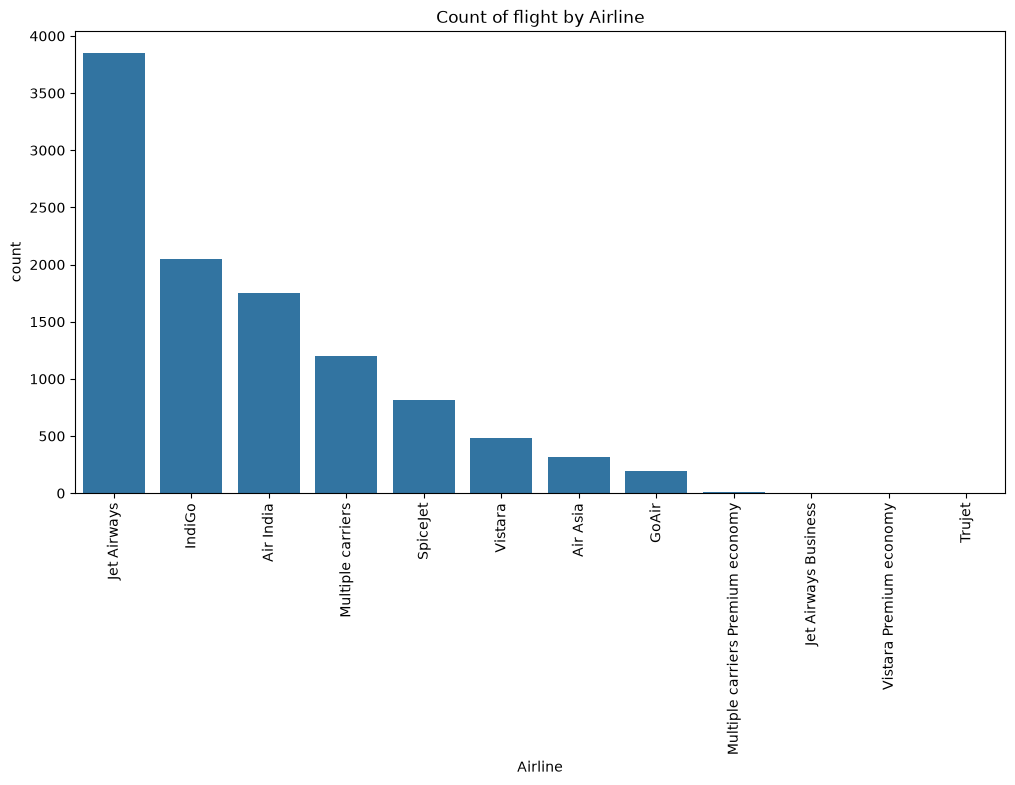

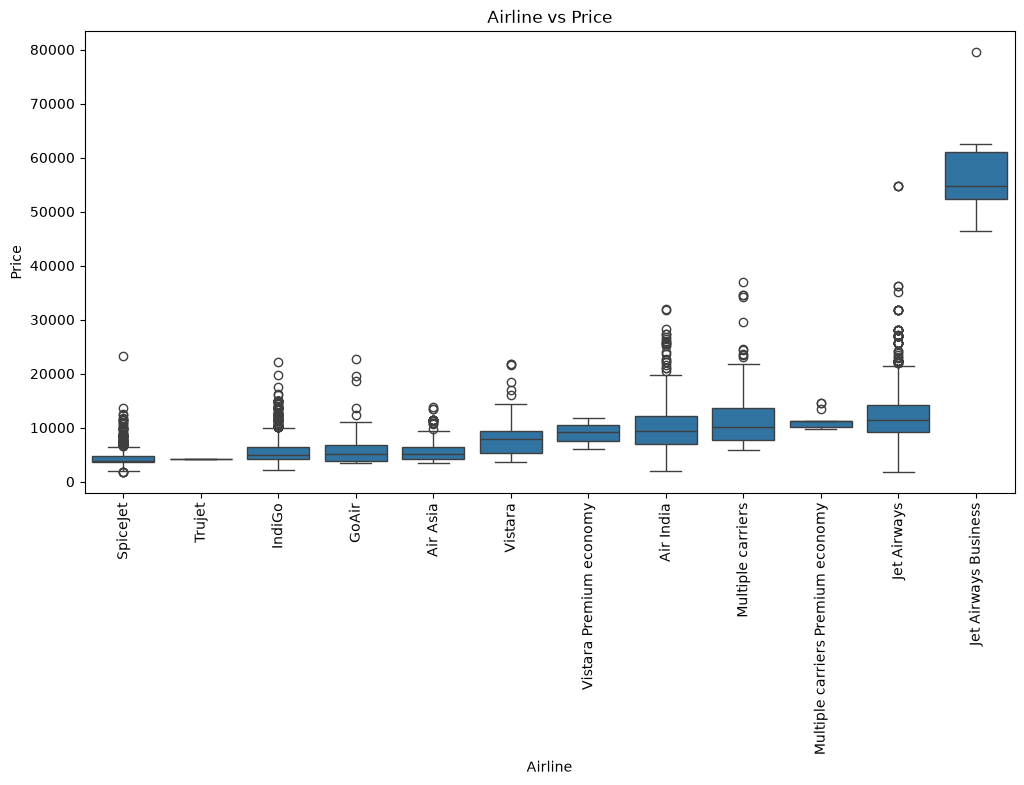

In [45]:
## Airline feature distribution
plt.figure(figsize=(12,6))
sns.countplot(data= train_data,x='Airline', order= train_data['Airline'].value_counts().index)
plt.title('Count of flight by Airline')
plt.xticks(rotation=90)
plt.show()

## Airline feature dependence on Price
plt.figure(figsize=(12,6))
sns.boxplot(data=train_data, x='Airline',y ='Price',
order= train_data.groupby('Airline')['Price'].median().sort_values().index)
plt.title('Airline vs Price')
plt.xticks(rotation=90)
plt.show()


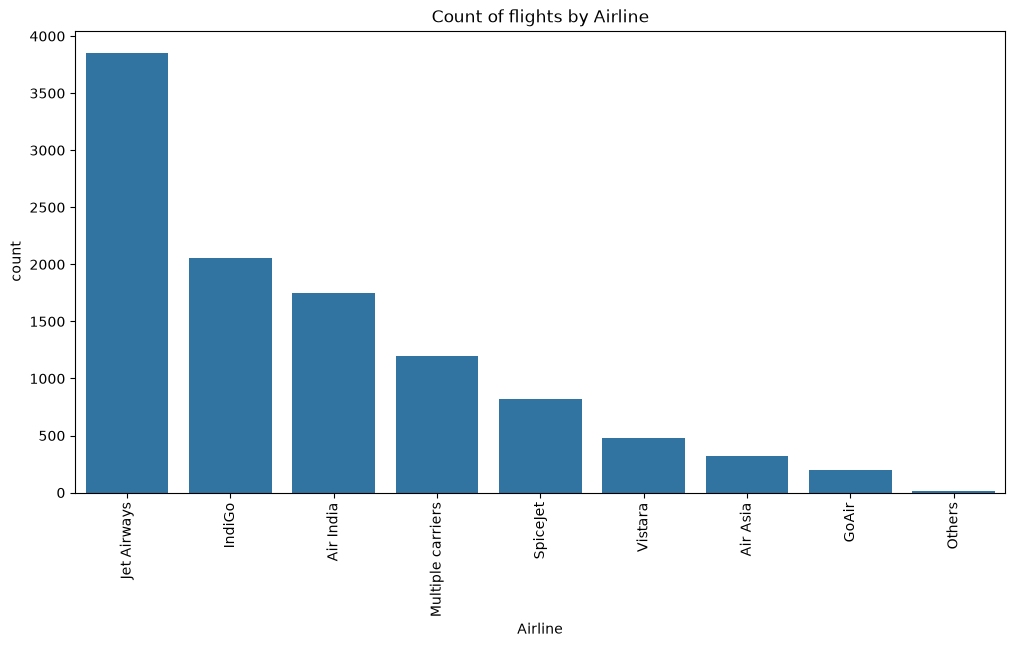

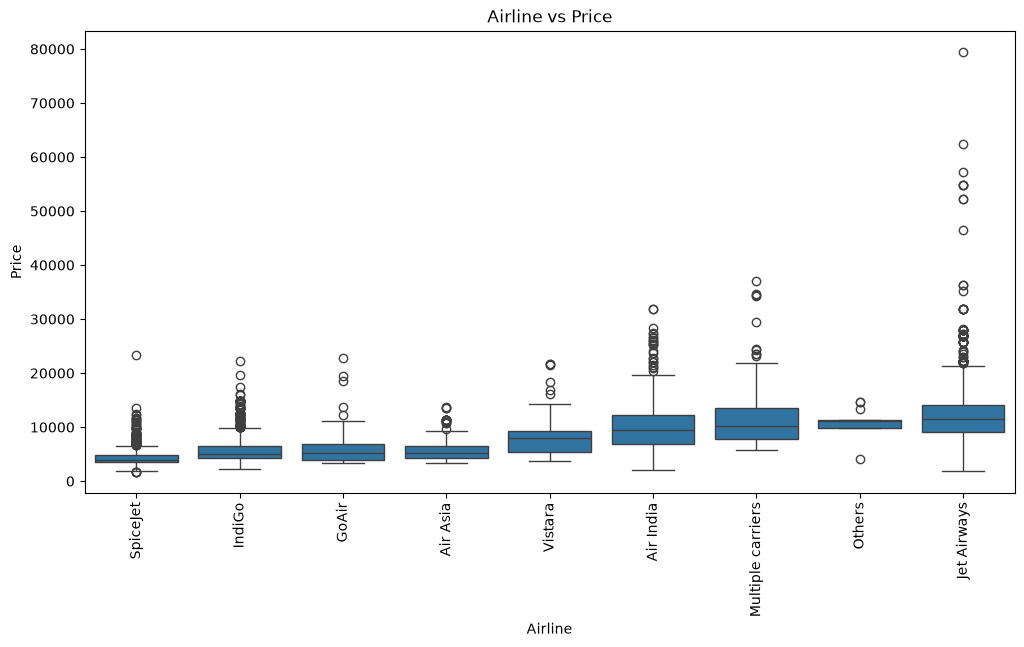

In [46]:
# Merging specified categories in the Airline
train_data['Airline']= train_data['Airline'].replace({
    'Vistara Premium economy': 'Vistara',
    'Jet Airways Business': 'Jet Airways',
    'Multiple carriers Premium economy': 'Others',
    'Trujet': 'Others'
})

test_data['Airline']= test_data['Airline'].replace({
    'Vistara Premium economy': 'Vistara',
    'Jet Airways Business': 'Jet Airways',
    'Multiple carriers Premium economy': 'Others',
    'Trujet': 'Others'
})


# Re-plotting the updated Airline feature
plt.figure(figsize=(12,6))
sns.countplot(data=train_data,x='Airline',order=train_data['Airline'].value_counts().index)
plt.title('Count of flights by Airline')
plt.xticks(rotation=90)
plt.show()

# Re-plotting the updated Airline feature dependance on Price
plt.figure(figsize=(12,6))
sns.boxplot(data=train_data, x='Airline',y ='Price',
order= train_data.groupby('Airline')['Price'].median().sort_values().index)
plt.title('Airline vs Price')
plt.xticks(rotation=90)
plt.show()


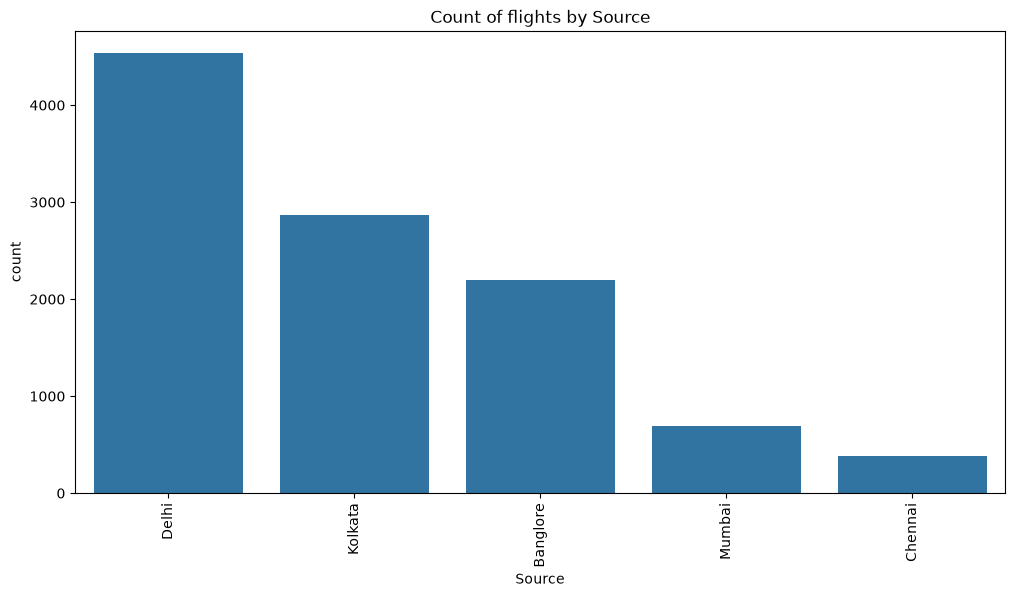

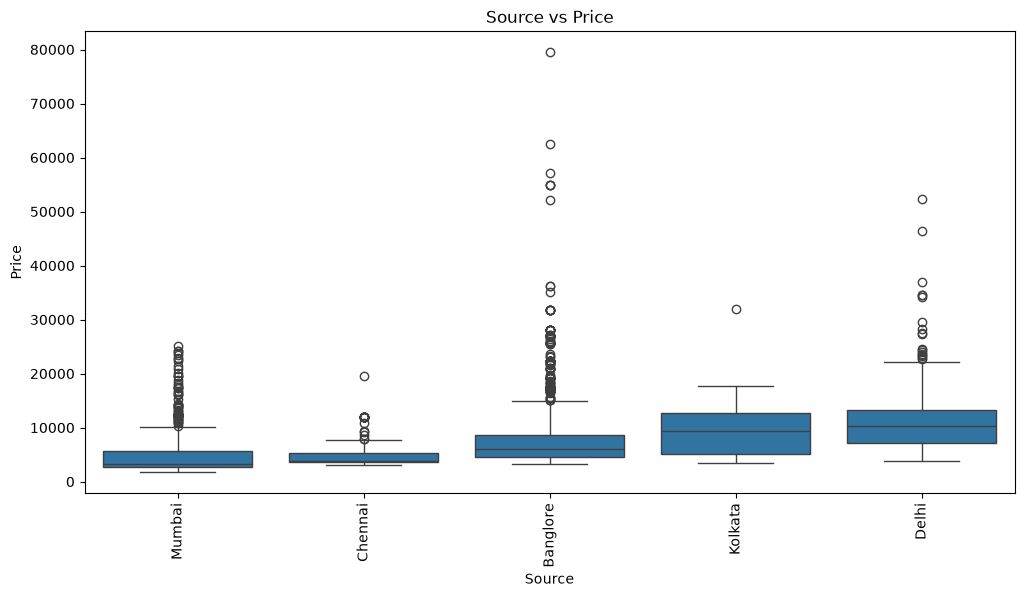

In [47]:
# Plotting Source Distribution
plt.figure(figsize=(12,6))
sns.countplot(data=train_data,x='Source',order=train_data['Source'].value_counts().index)
plt.title('Count of flights by Source')
plt.xticks(rotation=90)
plt.show()

# Source feature dependance on Price
plt.figure(figsize=(12,6))
sns.boxplot(data=train_data, x='Source',y ='Price',
order= train_data.groupby('Source')['Price'].median().sort_values().index)
plt.title('Source vs Price')
plt.xticks(rotation=90)
plt.show()


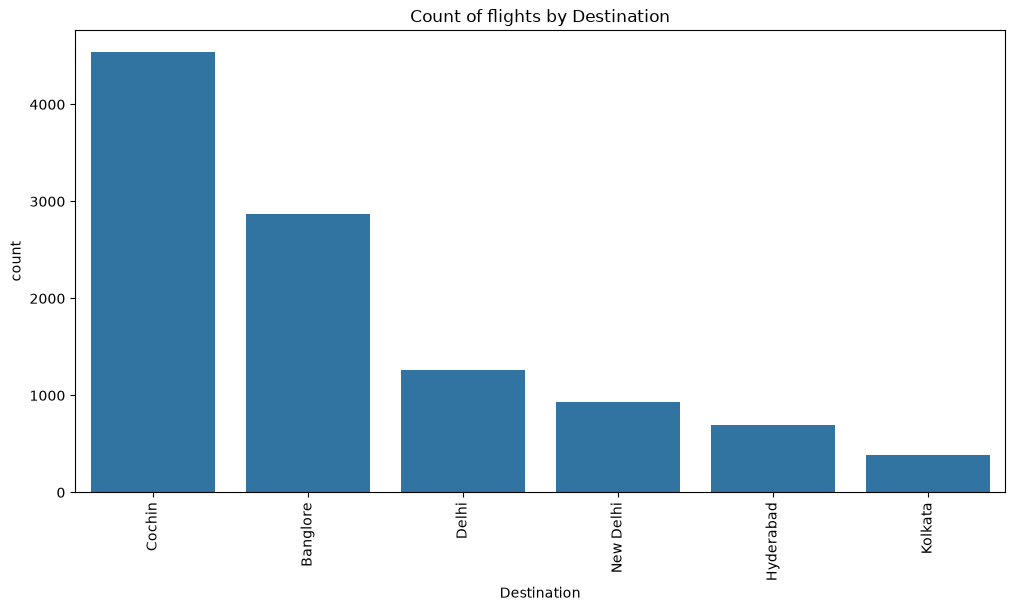

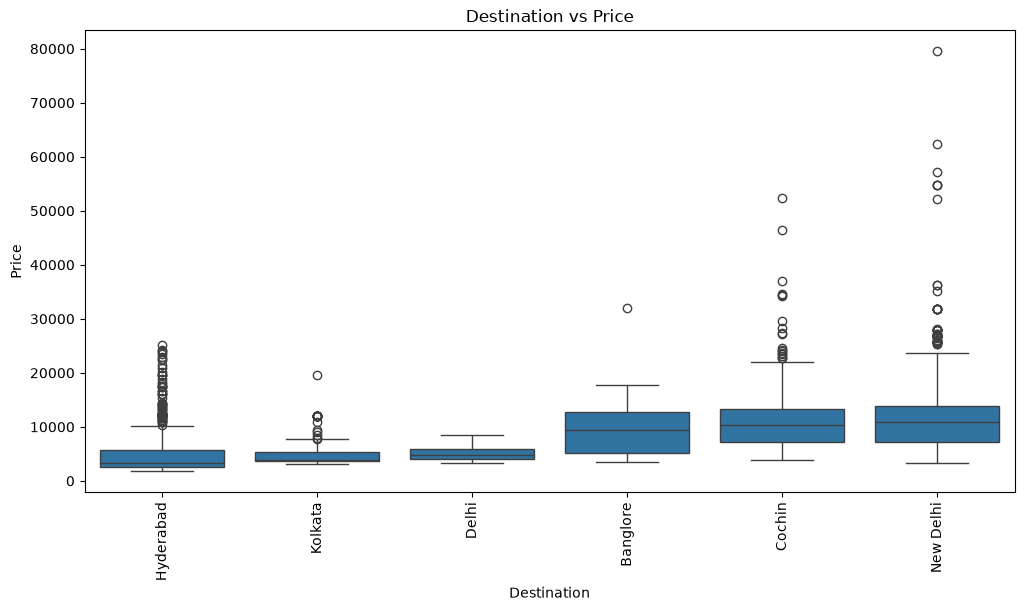

In [48]:
# Plotting Destination Distribution
plt.figure(figsize=(12,6))
sns.countplot(data=train_data,x='Destination',order=train_data['Destination'].value_counts().index)
plt.title('Count of flights by Destination')
plt.xticks(rotation=90)
plt.show()

# Destination feature dependance on Price
plt.figure(figsize=(12,6))
sns.boxplot(data=train_data, x='Destination',y ='Price',
order= train_data.groupby('Destination')['Price'].median().sort_values().index)
plt.title('Destination vs Price')
plt.xticks(rotation=90)
plt.show()


#### 14. Creating a new feature as Route popularity

In [49]:
# Route Popularity -1) combining the route using source - destination (source to destination)
train_data['Route']= train_data['Source']+ '-' + train_data['Destination']
test_data['Route']= test_data['Source']+ '-' + test_data['Destination']

In [50]:
train_data

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Journey_Day_of_Week,Is_Weekend,Dep_Part_of_Day,Num_Routes,Arrival_Part_Of_Day,Duration_Hours,Route
0,IndiGo,Banglore,New Delhi,non-stop,No info,3897,24,3,6,1,Night,2,Night,2.833333,Banglore-New Delhi
1,Air India,Kolkata,Banglore,2 stops,No info,7662,1,5,2,0,Morning,4,Afternoon,7.416667,Kolkata-Banglore
2,Jet Airways,Delhi,Cochin,2 stops,No info,13882,9,6,6,1,Morning,4,Night,19.000000,Delhi-Cochin
3,IndiGo,Kolkata,Banglore,1 stop,No info,6218,12,5,6,1,Evening,3,Night,5.416667,Kolkata-Banglore
4,IndiGo,Banglore,New Delhi,1 stop,No info,13302,1,3,4,0,Afternoon,3,Night,4.750000,Banglore-New Delhi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,non-stop,No info,4107,9,4,1,0,Evening,2,Night,2.500000,Kolkata-Banglore
10679,Air India,Kolkata,Banglore,non-stop,No info,4145,27,4,5,1,Evening,2,Night,2.583333,Kolkata-Banglore
10680,Jet Airways,Banglore,Delhi,non-stop,No info,7229,27,4,5,1,Morning,2,Morning,3.000000,Banglore-Delhi
10681,Vistara,Banglore,New Delhi,non-stop,No info,12648,1,3,4,0,Morning,2,Afternoon,2.666667,Banglore-New Delhi


In [51]:
# checking the count for more route popularity

route_popularity = train_data['Route'].value_counts()
route_popularity

Route
Delhi-Cochin          4536
Kolkata-Banglore      2871
Banglore-Delhi        1265
Banglore-New Delhi     932
Mumbai-Hyderabad       697
Chennai-Kolkata        381
Name: count, dtype: int64

In [52]:
#mapping these routes

train_data['Route_Popularity']= train_data['Route'].map(route_popularity)
test_data['Route_Popularity']= test_data['Route'].map(route_popularity)
train_data

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Journey_Day_of_Week,Is_Weekend,Dep_Part_of_Day,Num_Routes,Arrival_Part_Of_Day,Duration_Hours,Route,Route_Popularity
0,IndiGo,Banglore,New Delhi,non-stop,No info,3897,24,3,6,1,Night,2,Night,2.833333,Banglore-New Delhi,932
1,Air India,Kolkata,Banglore,2 stops,No info,7662,1,5,2,0,Morning,4,Afternoon,7.416667,Kolkata-Banglore,2871
2,Jet Airways,Delhi,Cochin,2 stops,No info,13882,9,6,6,1,Morning,4,Night,19.000000,Delhi-Cochin,4536
3,IndiGo,Kolkata,Banglore,1 stop,No info,6218,12,5,6,1,Evening,3,Night,5.416667,Kolkata-Banglore,2871
4,IndiGo,Banglore,New Delhi,1 stop,No info,13302,1,3,4,0,Afternoon,3,Night,4.750000,Banglore-New Delhi,932
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,non-stop,No info,4107,9,4,1,0,Evening,2,Night,2.500000,Kolkata-Banglore,2871
10679,Air India,Kolkata,Banglore,non-stop,No info,4145,27,4,5,1,Evening,2,Night,2.583333,Kolkata-Banglore,2871
10680,Jet Airways,Banglore,Delhi,non-stop,No info,7229,27,4,5,1,Morning,2,Morning,3.000000,Banglore-Delhi,1265
10681,Vistara,Banglore,New Delhi,non-stop,No info,12648,1,3,4,0,Morning,2,Afternoon,2.666667,Banglore-New Delhi,932


In [53]:
# Drop the 'Route' feature as it's no longer needed
train_data.drop('Route',axis=1,inplace= True)
test_data.drop('Route', axis=1,inplace= True)

In [54]:
train_data

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Journey_Day_of_Week,Is_Weekend,Dep_Part_of_Day,Num_Routes,Arrival_Part_Of_Day,Duration_Hours,Route_Popularity
0,IndiGo,Banglore,New Delhi,non-stop,No info,3897,24,3,6,1,Night,2,Night,2.833333,932
1,Air India,Kolkata,Banglore,2 stops,No info,7662,1,5,2,0,Morning,4,Afternoon,7.416667,2871
2,Jet Airways,Delhi,Cochin,2 stops,No info,13882,9,6,6,1,Morning,4,Night,19.000000,4536
3,IndiGo,Kolkata,Banglore,1 stop,No info,6218,12,5,6,1,Evening,3,Night,5.416667,2871
4,IndiGo,Banglore,New Delhi,1 stop,No info,13302,1,3,4,0,Afternoon,3,Night,4.750000,932
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,non-stop,No info,4107,9,4,1,0,Evening,2,Night,2.500000,2871
10679,Air India,Kolkata,Banglore,non-stop,No info,4145,27,4,5,1,Evening,2,Night,2.583333,2871
10680,Jet Airways,Banglore,Delhi,non-stop,No info,7229,27,4,5,1,Morning,2,Morning,3.000000,1265
10681,Vistara,Banglore,New Delhi,non-stop,No info,12648,1,3,4,0,Morning,2,Afternoon,2.666667,932


## 15. Total stops

In [55]:
train_data['Total_Stops'].value_counts()

Total_Stops
1 stop      5625
non-stop    3491
2 stops     1520
3 stops       45
4 stops        1
Name: count, dtype: int64

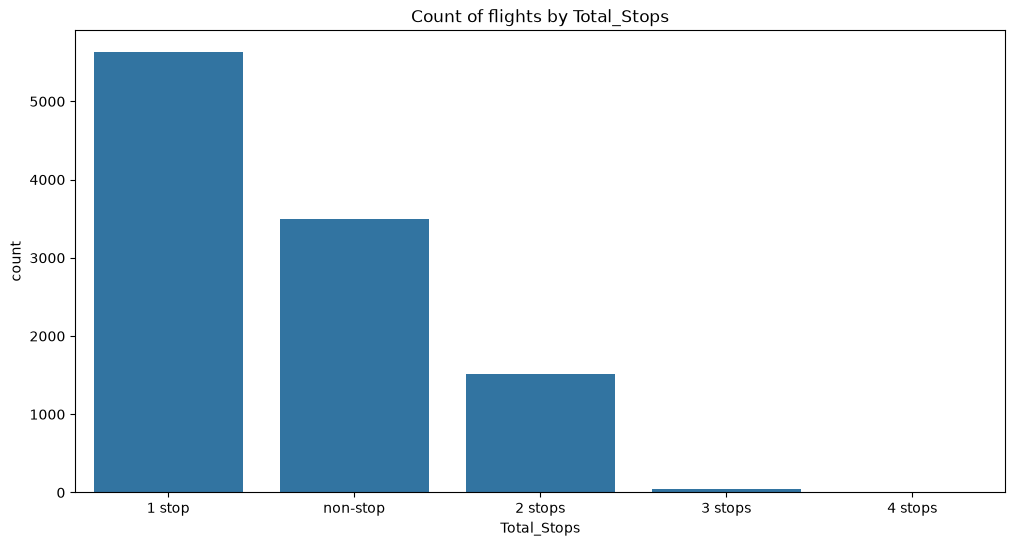

In [56]:
#  Distribution of Toatl_Stops

plt.figure(figsize=(12,6))
sns.countplot(data=train_data,x='Total_Stops',order=train_data['Total_Stops'].value_counts().index)
plt.title('Count of flights by Total_Stops')
plt.show()

In [57]:
## Converting the Total_Stops feature into numerical by mapping it with integer values

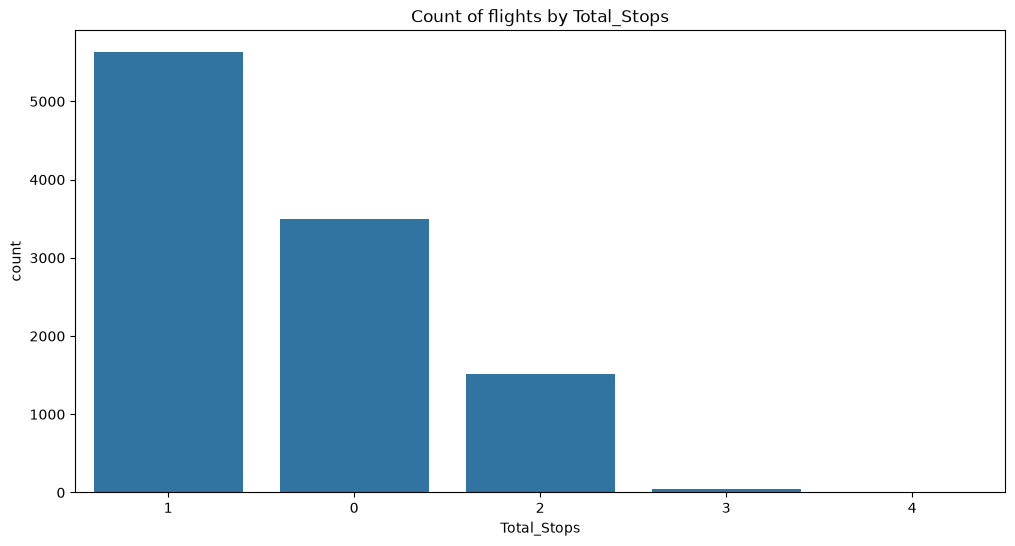

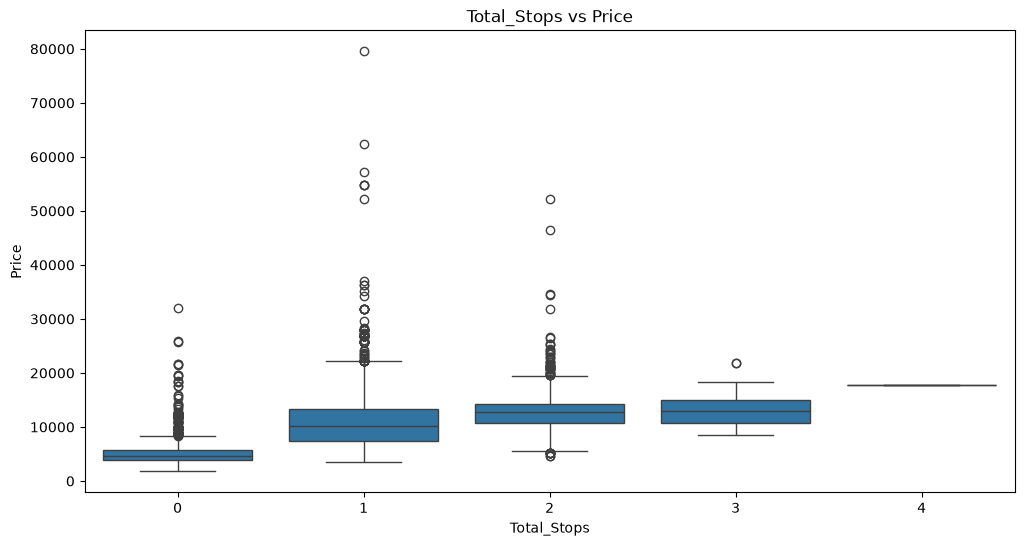

In [58]:
## Convert categories of Total_Stops feature

train_data['Total_Stops']= train_data['Total_Stops'].replace({
    'non-stop': 0,
    '1 stop': 1,
    '2 stops': 2,
    '3 stops': 3,
    '4 stops': 4
})

test_data['Total_Stops']= test_data['Total_Stops'].replace({
    'non-stop': 0,
    '1 stop': 1,
    '2 stops': 2,
    '3 stops': 3,
    '4 stops': 4
})


# Distribution of Total_Stops
plt.figure(figsize=(12,6))
sns.countplot(data=train_data,x='Total_Stops',order=train_data['Total_Stops'].value_counts().index)
plt.title('Count of flights by Total_Stops')
plt.show()

# Total_Stops feature dependence on Price
plt.figure(figsize=(12,6))
sns.boxplot(data=train_data, x='Total_Stops',y ='Price',
order= train_data.groupby('Total_Stops')['Price'].median().sort_values().index)
plt.title('Total_Stops vs Price')
plt.show()


### 16. Additional Info

In [59]:
train_data['Additional_Info'].value_counts()

Additional_Info
No info                         8344
In-flight meal not included     1982
No check-in baggage included     320
1 Long layover                    19
Change airports                    7
Business class                     4
No Info                            3
1 Short layover                    1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64

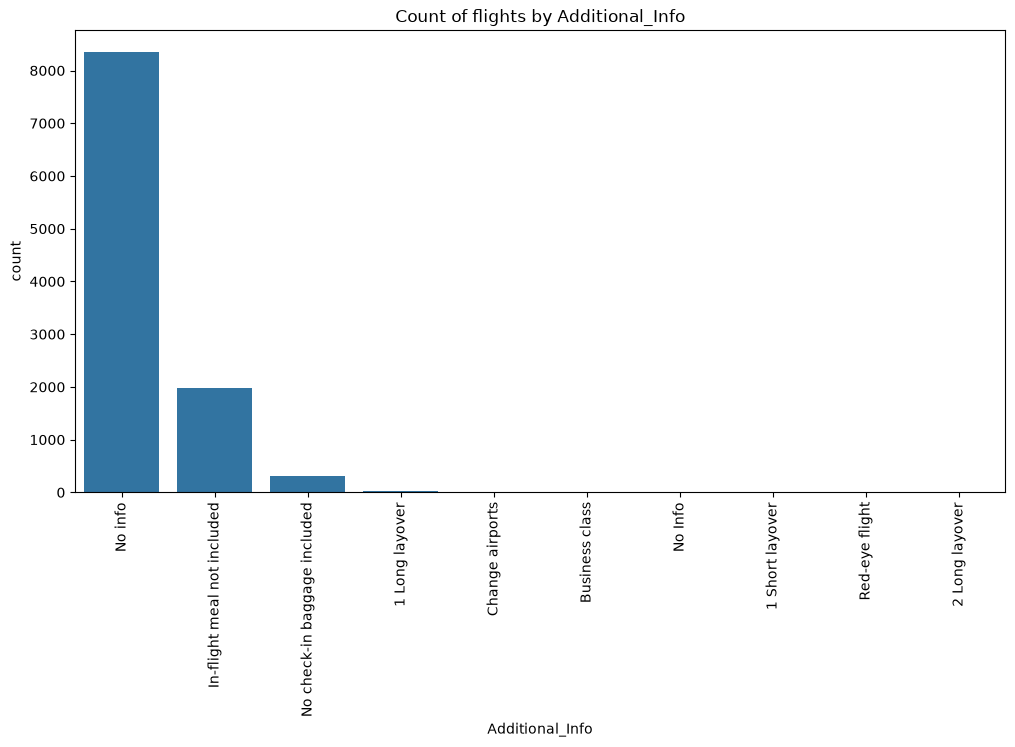

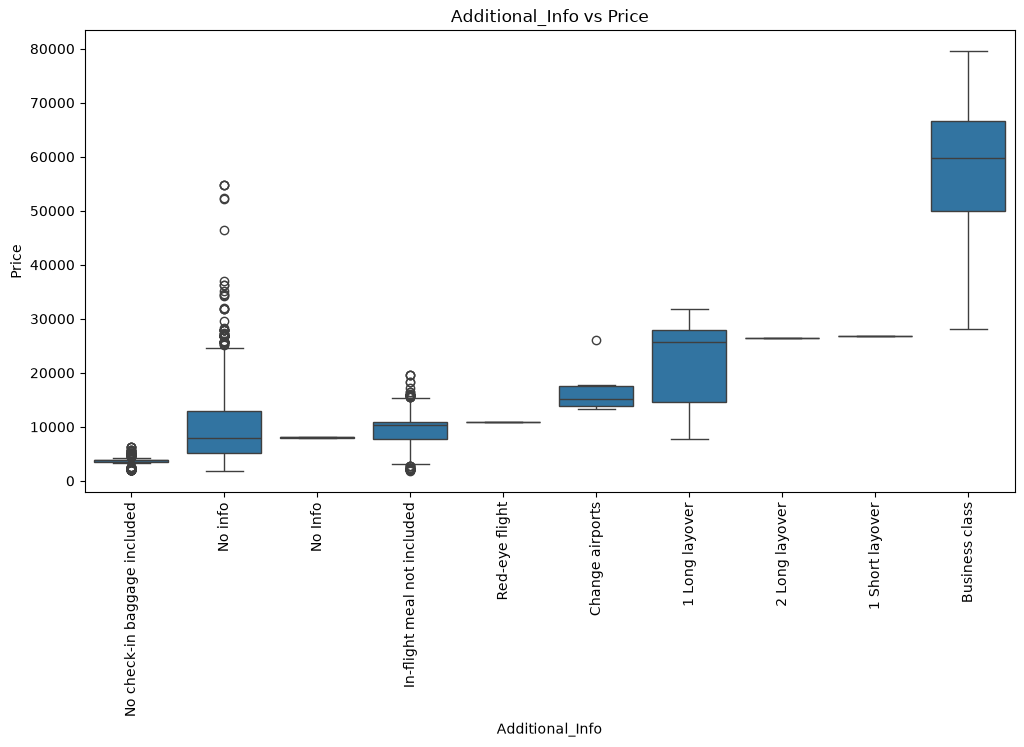

In [60]:
# Distribution of Additional_info
plt.figure(figsize=(12,6))
sns.countplot(data=train_data,x='Additional_Info',order=train_data['Additional_Info'].value_counts().index)
plt.title('Count of flights by Additional_Info')
plt.xticks(rotation=90)
plt.show()

# Additional_Info feature dependence on Price
plt.figure(figsize=(12,6))
sns.boxplot(data=train_data, x='Additional_Info',y ='Price',
order= train_data.groupby('Additional_Info')['Price'].median().sort_values().index)
plt.title('Additional_Info vs Price')
plt.xticks(rotation=90)
plt.show()


In [61]:
train_data['Additional_Info']= train_data['Additional_Info'].replace({
    'No Info': 'No info' #2 No info are present (merging in one)
})

test_data['Additional_Info']= test_data['Additional_Info'].replace({
    'No Info': 'No info' 
})


In [62]:
train_data['Additional_Info'].value_counts()

Additional_Info
No info                         8347
In-flight meal not included     1982
No check-in baggage included     320
1 Long layover                    19
Change airports                    7
Business class                     4
1 Short layover                    1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64

In [63]:
# Calculate the frequency of each category
additional_info_counts = train_data['Additional_Info'].value_counts()

# Define a threshold to identify rare categories
threshold = 100 # You can adjust this threshold based on the dataset

# Identify rare Categories
rare_Categories = additional_info_counts[additional_info_counts < threshold].index.to_list()


# Print the rare categories

rare_Categories

['1 Long layover',
 'Change airports',
 'Business class',
 '1 Short layover',
 'Red-eye flight',
 '2 Long layover']

In [64]:
# Merge rare Categories into 'Other'

train_data['Additional_Info']= train_data['Additional_Info'].apply(lambda x: 'Other' if x in rare_Categories else x)
test_data['Additional_Info']= test_data['Additional_Info'].apply(lambda x: 'Other' if x in rare_Categories else x)


# Verifying the Changes
train_data['Additional_Info'].value_counts()

Additional_Info
No info                         8347
In-flight meal not included     1982
No check-in baggage included     320
Other                             33
Name: count, dtype: int64

In [65]:
train_data

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Journey_Day_of_Week,Is_Weekend,Dep_Part_of_Day,Num_Routes,Arrival_Part_Of_Day,Duration_Hours,Route_Popularity
0,IndiGo,Banglore,New Delhi,0,No info,3897,24,3,6,1,Night,2,Night,2.833333,932
1,Air India,Kolkata,Banglore,2,No info,7662,1,5,2,0,Morning,4,Afternoon,7.416667,2871
2,Jet Airways,Delhi,Cochin,2,No info,13882,9,6,6,1,Morning,4,Night,19.000000,4536
3,IndiGo,Kolkata,Banglore,1,No info,6218,12,5,6,1,Evening,3,Night,5.416667,2871
4,IndiGo,Banglore,New Delhi,1,No info,13302,1,3,4,0,Afternoon,3,Night,4.750000,932
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,0,No info,4107,9,4,1,0,Evening,2,Night,2.500000,2871
10679,Air India,Kolkata,Banglore,0,No info,4145,27,4,5,1,Evening,2,Night,2.583333,2871
10680,Jet Airways,Banglore,Delhi,0,No info,7229,27,4,5,1,Morning,2,Morning,3.000000,1265
10681,Vistara,Banglore,New Delhi,0,No info,12648,1,3,4,0,Morning,2,Afternoon,2.666667,932


In [66]:
train_data.corr

<bound method DataFrame.corr of            Airline    Source Destination Total_Stops Additional_Info  Price  \
0           IndiGo  Banglore   New Delhi           0         No info   3897   
1        Air India   Kolkata    Banglore           2         No info   7662   
2      Jet Airways     Delhi      Cochin           2         No info  13882   
3           IndiGo   Kolkata    Banglore           1         No info   6218   
4           IndiGo  Banglore   New Delhi           1         No info  13302   
...            ...       ...         ...         ...             ...    ...   
10678     Air Asia   Kolkata    Banglore           0         No info   4107   
10679    Air India   Kolkata    Banglore           0         No info   4145   
10680  Jet Airways  Banglore       Delhi           0         No info   7229   
10681      Vistara  Banglore   New Delhi           0         No info  12648   
10682    Air India     Delhi      Cochin           2         No info  11753   

       Journey_Day 

# Predicting the Model

In [67]:
train_data.to_excel("alirline_price_train_after_cleaning.xlsx")
test_data.to_excel("alirline_price_test_after_cleaning.xlsx")

# Correlation Matrix

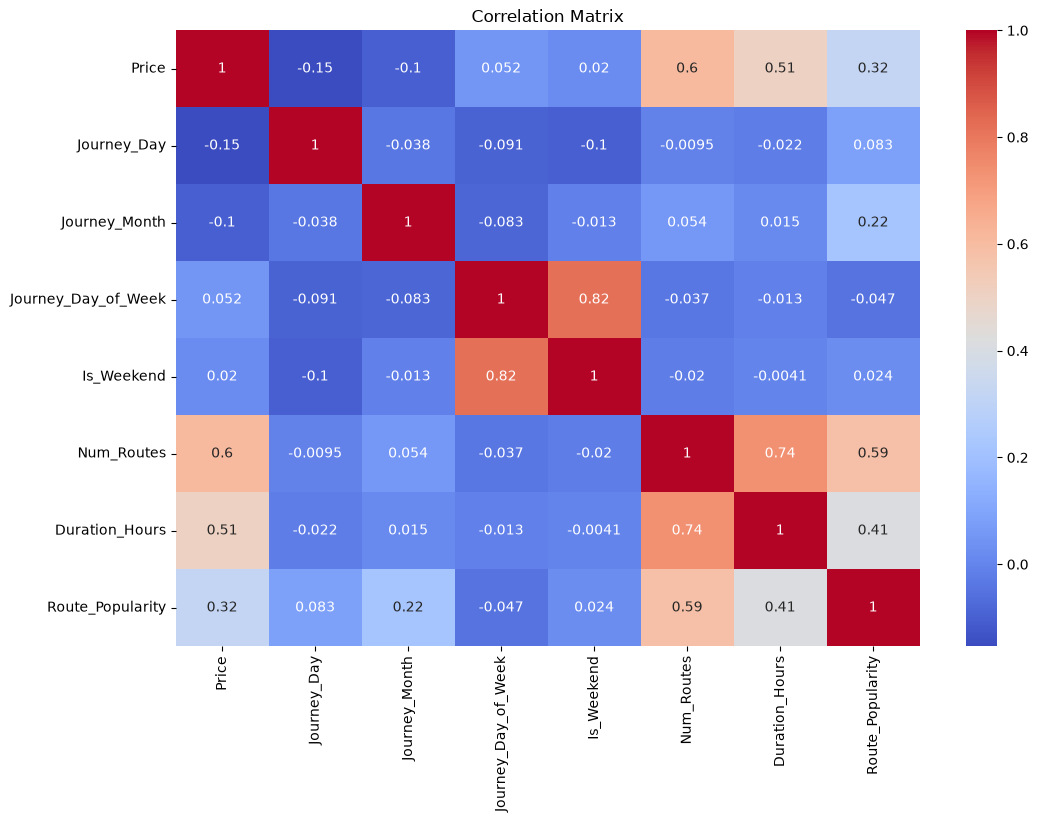

In [68]:
corr_matrix= train_data.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## Number of routes and Total_Stops have correlation =1, therefore removing one of them "Num_Routes

In [69]:
# Drop the 'Route' feature as it's no longer needed

train_data.drop('Num_Routes', axis=1, inplace= True)
test_data.drop('Num_Routes', axis=1, inplace= True)

In [70]:
train_data

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Journey_Day_of_Week,Is_Weekend,Dep_Part_of_Day,Arrival_Part_Of_Day,Duration_Hours,Route_Popularity
0,IndiGo,Banglore,New Delhi,0,No info,3897,24,3,6,1,Night,Night,2.833333,932
1,Air India,Kolkata,Banglore,2,No info,7662,1,5,2,0,Morning,Afternoon,7.416667,2871
2,Jet Airways,Delhi,Cochin,2,No info,13882,9,6,6,1,Morning,Night,19.000000,4536
3,IndiGo,Kolkata,Banglore,1,No info,6218,12,5,6,1,Evening,Night,5.416667,2871
4,IndiGo,Banglore,New Delhi,1,No info,13302,1,3,4,0,Afternoon,Night,4.750000,932
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,0,No info,4107,9,4,1,0,Evening,Night,2.500000,2871
10679,Air India,Kolkata,Banglore,0,No info,4145,27,4,5,1,Evening,Night,2.583333,2871
10680,Jet Airways,Banglore,Delhi,0,No info,7229,27,4,5,1,Morning,Morning,3.000000,1265
10681,Vistara,Banglore,New Delhi,0,No info,12648,1,3,4,0,Morning,Afternoon,2.666667,932


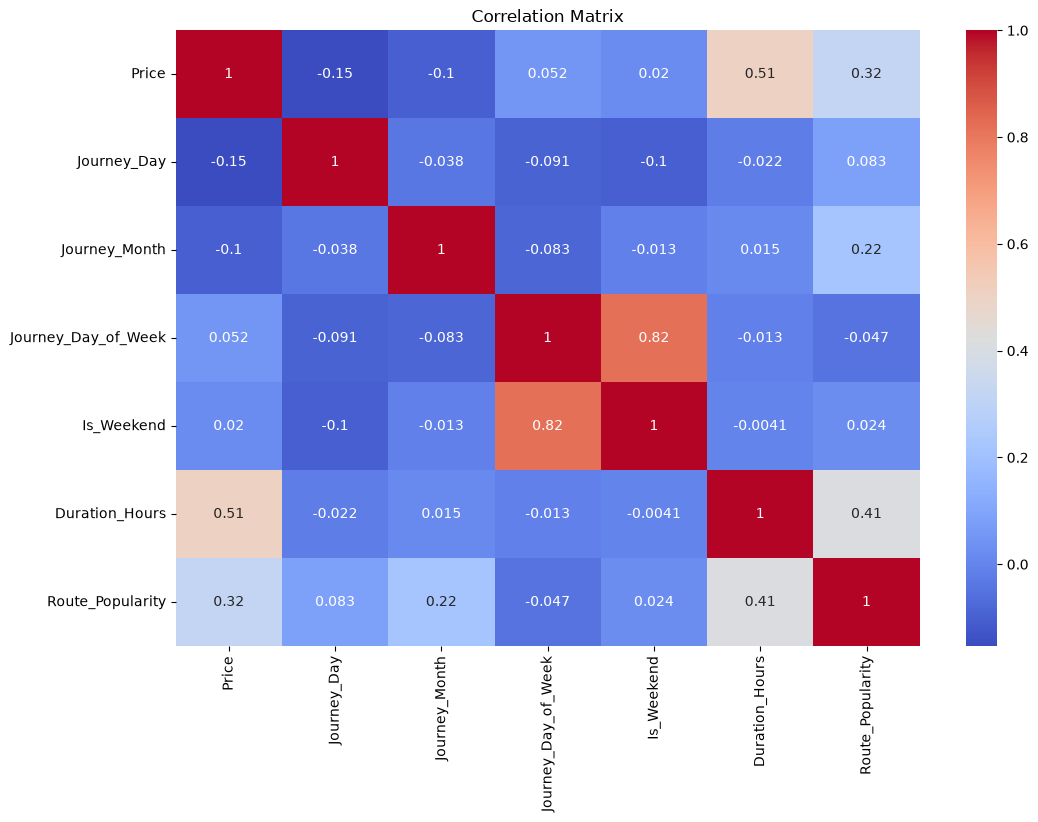

In [71]:
corr_matrix= train_data.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [72]:
train_data.shape

(10682, 14)

In [73]:
train_data.columns

Index(['Airline', 'Source', 'Destination', 'Total_Stops', 'Additional_Info',
       'Price', 'Journey_Day', 'Journey_Month', 'Journey_Day_of_Week',
       'Is_Weekend', 'Dep_Part_of_Day', 'Arrival_Part_Of_Day',
       'Duration_Hours', 'Route_Popularity'],
      dtype='str')

#### Encoding and NO Standadization

In [74]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [75]:
# Seperate the feature and the target

x= train_data.drop(columns=['Price'])
y= train_data['Price'] # Target Variable

In [76]:
x

,Airline,Source,Destination,Total_Stops,Additional_Info,Journey_Day,Journey_Month,Journey_Day_of_Week,Is_Weekend,Dep_Part_of_Day,Arrival_Part_Of_Day,Duration_Hours,Route_Popularity
0,IndiGo,Banglore,New Delhi,0,No info,24,3,6,1,Night,Night,2.833333,932
1,Air India,Kolkata,Banglore,2,No info,1,5,2,0,Morning,Afternoon,7.416667,2871
2,Jet Airways,Delhi,Cochin,2,No info,9,6,6,1,Morning,Night,19.000000,4536
3,IndiGo,Kolkata,Banglore,1,No info,12,5,6,1,Evening,Night,5.416667,2871
4,IndiGo,Banglore,New Delhi,1,No info,1,3,4,0,Afternoon,Night,4.750000,932
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,0,No info,9,4,1,0,Evening,Night,2.500000,2871
10679,Air India,Kolkata,Banglore,0,No info,27,4,5,1,Evening,Night,2.583333,2871
10680,Jet Airways,Banglore,Delhi,0,No info,27,4,5,1,Morning,Morning,3.000000,1265
10681,Vistara,Banglore,New Delhi,0,No info,1,3,4,0,Morning,Afternoon,2.666667,932


In [77]:
y

0         3897
1         7662
2        13882
3         6218
4        13302
         ...  
10678     4107
10679     4145
10680     7229
10681    12648
10682    11753
Name: Price, Length: 10682, dtype: int64

In [78]:
# Define Categorical and numerical features
categorical_features = ['Airline','Source', 'Destination', 'Additional_Info', 'Dep_Part_of_Day', 'Arrival_Part_Of_Day']

numerical_features = x.select_dtypes(include=['int64','float64']).columns.tolist()


In [79]:
categorical_features

['Airline',
 'Source',
 'Destination',
 'Additional_Info',
 'Dep_Part_of_Day',
 'Arrival_Part_Of_Day']

In [80]:
numerical_features

['Journey_Day_of_Week', 'Is_Weekend', 'Duration_Hours', 'Route_Popularity']

In [81]:
# Perform one-hot encoding on categorical features
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, drop='first')
x_encoded = encoder.fit_transform(x[categorical_features])

x_encoded

array([[0., 0., 1., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 1., 0., 0.]], shape=(10682, 26))

In [82]:
# convert the encoded features back to df
x_encoded_df = pd.DataFrame(x_encoded, columns=encoder.get_feature_names_out(categorical_features))
x_encoded_df

,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Multiple carriers,Airline_Others,Airline_SpiceJet,Airline_Vistara,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi,Additional_Info_No check-in baggage included,Additional_Info_No info,Additional_Info_Other,Dep_Part_of_Day_Evening,Dep_Part_of_Day_Morning,Dep_Part_of_Day_Night,Arrival_Part_Of_Day_Evening,Arrival_Part_Of_Day_Morning,Arrival_Part_Of_Day_Night
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10677,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
10678,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
10679,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
10680,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [83]:
x_encoded_df.shape

(10682, 26)

In [84]:
x_numerical = x.drop(columns=categorical_features).reset_index(drop= True)

In [85]:
# Concatenate the encoded and scaled features
x_final= pd.concat([x_numerical, x_encoded_df.reset_index(drop= True)],axis =1)
x_final

,Total_Stops,Journey_Day,Journey_Month,Journey_Day_of_Week,Is_Weekend,Duration_Hours,Route_Popularity,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Multiple carriers,Airline_Others,Airline_SpiceJet,Airline_Vistara,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi,Additional_Info_No check-in baggage included,Additional_Info_No info,Additional_Info_Other,Dep_Part_of_Day_Evening,Dep_Part_of_Day_Morning,Dep_Part_of_Day_Night,Arrival_Part_Of_Day_Evening,Arrival_Part_Of_Day_Morning,Arrival_Part_Of_Day_Night
0,0,24,3,6,1,2.833333,932,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,2,1,5,2,0,7.416667,2871,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,2,9,6,6,1,19.000000,4536,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,1,12,5,6,1,5.416667,2871,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,1,1,3,4,0,4.750000,932,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10677,0,9,4,1,0,2.500000,2871,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
10678,0,27,4,5,1,2.583333,2871,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
10679,0,27,4,5,1,3.000000,1265,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
10680,0,1,3,4,0,2.666667,932,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [86]:
x_final.shape

(10682, 33)

In [87]:
### Train Test Split data on training data itself

In [88]:
## Split the data into training and testing sets
x_train,x_test,y_train,y_test= train_test_split(x_final, y,
test_size=0.2,random_state= 42)

In [89]:
x_train

,Total_Stops,Journey_Day,Journey_Month,Journey_Day_of_Week,Is_Weekend,Duration_Hours,Route_Popularity,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Multiple carriers,Airline_Others,Airline_SpiceJet,Airline_Vistara,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi,Additional_Info_No check-in baggage included,Additional_Info_No info,Additional_Info_Other,Dep_Part_of_Day_Evening,Dep_Part_of_Day_Morning,Dep_Part_of_Day_Night,Arrival_Part_Of_Day_Evening,Arrival_Part_Of_Day_Morning,Arrival_Part_Of_Day_Night
10004,1,27,5,0,0,10.750000,4536,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3684,1,9,5,3,0,25.083333,4536,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1034,1,24,4,2,0,6.333333,4536,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3909,1,21,3,3,0,12.750000,4536,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3088,2,24,6,0,0,26.000000,4536,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,1,27,3,2,0,19.416667,4536,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
5191,1,9,5,3,0,6.666667,2871,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5390,1,15,5,2,0,12.666667,4536,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
860,0,3,3,6,1,2.750000,932,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [90]:

x_test

,Total_Stops,Journey_Day,Journey_Month,Journey_Day_of_Week,Is_Weekend,Duration_Hours,Route_Popularity,Airline_Air India,Airline_GoAir,Airline_IndiGo,Airline_Jet Airways,Airline_Multiple carriers,Airline_Others,Airline_SpiceJet,Airline_Vistara,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi,Additional_Info_No check-in baggage included,Additional_Info_No info,Additional_Info_Other,Dep_Part_of_Day_Evening,Dep_Part_of_Day_Morning,Dep_Part_of_Day_Night,Arrival_Part_Of_Day_Evening,Arrival_Part_Of_Day_Morning,Arrival_Part_Of_Day_Night
6075,2,21,5,1,0,10.416667,4536,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3544,1,3,6,0,0,9.000000,4536,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
9290,1,9,5,3,0,12.750000,2871,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
5032,0,24,5,4,0,2.333333,381,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2483,1,21,5,1,0,5.583333,4536,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9796,1,27,6,3,0,13.000000,4536,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
9870,0,6,3,2,0,2.500000,2871,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
10062,1,21,4,6,1,14.500000,4536,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
8802,1,24,3,6,1,16.916667,2871,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [91]:
# Initialize and train the Linear Regression model

model=LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](33,)","[2595.59, -63.25,-388.73,..., 83.07,-103.56,-276.88]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](33,)","['Total_Stops','Journey_Day','Journey_Month',..., 'Arrival_Part_Of_Day_Evening','Arrival_Part_Of_Day_Morning', 'Arrival_Part_Of_Day_Night']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3008
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,33
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(28)


In [92]:
# Predict on test set

y_pred= model.predict(x_test)

In [93]:
## Calculate evaluation metrics

mse= mean_squared_error(y_test,y_pred)
rmse= np.sqrt(mse)
mae= mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

adjusted_r2= 1-(1-r2) * (len(y_test)-1)/(len(y_test)- x_test.shape[1]-1)

In [94]:
# Print the results
print("Linear Regression Performance:")
print(f"Mean Squared Error (MSE): {mse : 4f}")
print(f"Root Mean Squared Error (RMSE): {rmse : 4f}")
print(f"Mean Absolute Error (MAE): { mae: 4f}")
print(f"R2 Score : {r2: 4f}")
print(f"Adjusted R2 Score: {adjusted_r2: 4f}")

Linear Regression Performance:
Mean Squared Error (MSE):  6868382.420511
Root Mean Squared Error (RMSE):  2620.759894
Mean Absolute Error (MAE):  1766.474844
R2 Score :  0.681460
Adjusted R2 Score:  0.676461


In [95]:
!pip install xgboost


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [96]:
!pip install tqdm


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [97]:
!pip install lightgbm


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [98]:
import time
from sklearn.linear_model import LinearRegression,Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor,GradientBoostingRegressor, ExtraTreesRegressor, VotingRegressor, StackingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from tqdm import tqdm
import matplotlib.pyplot as plt


 79%|███████▊  | 11/14 [00:31<00:07,  2.45s/it]

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000551 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 359
[LightGBM] [Info] Number of data points in the train set: 8545, number of used features: 41
[LightGBM] [Info] Start training from score 9078.336688


100%|██████████| 14/14 [00:01<00:00,  7.79it/s]


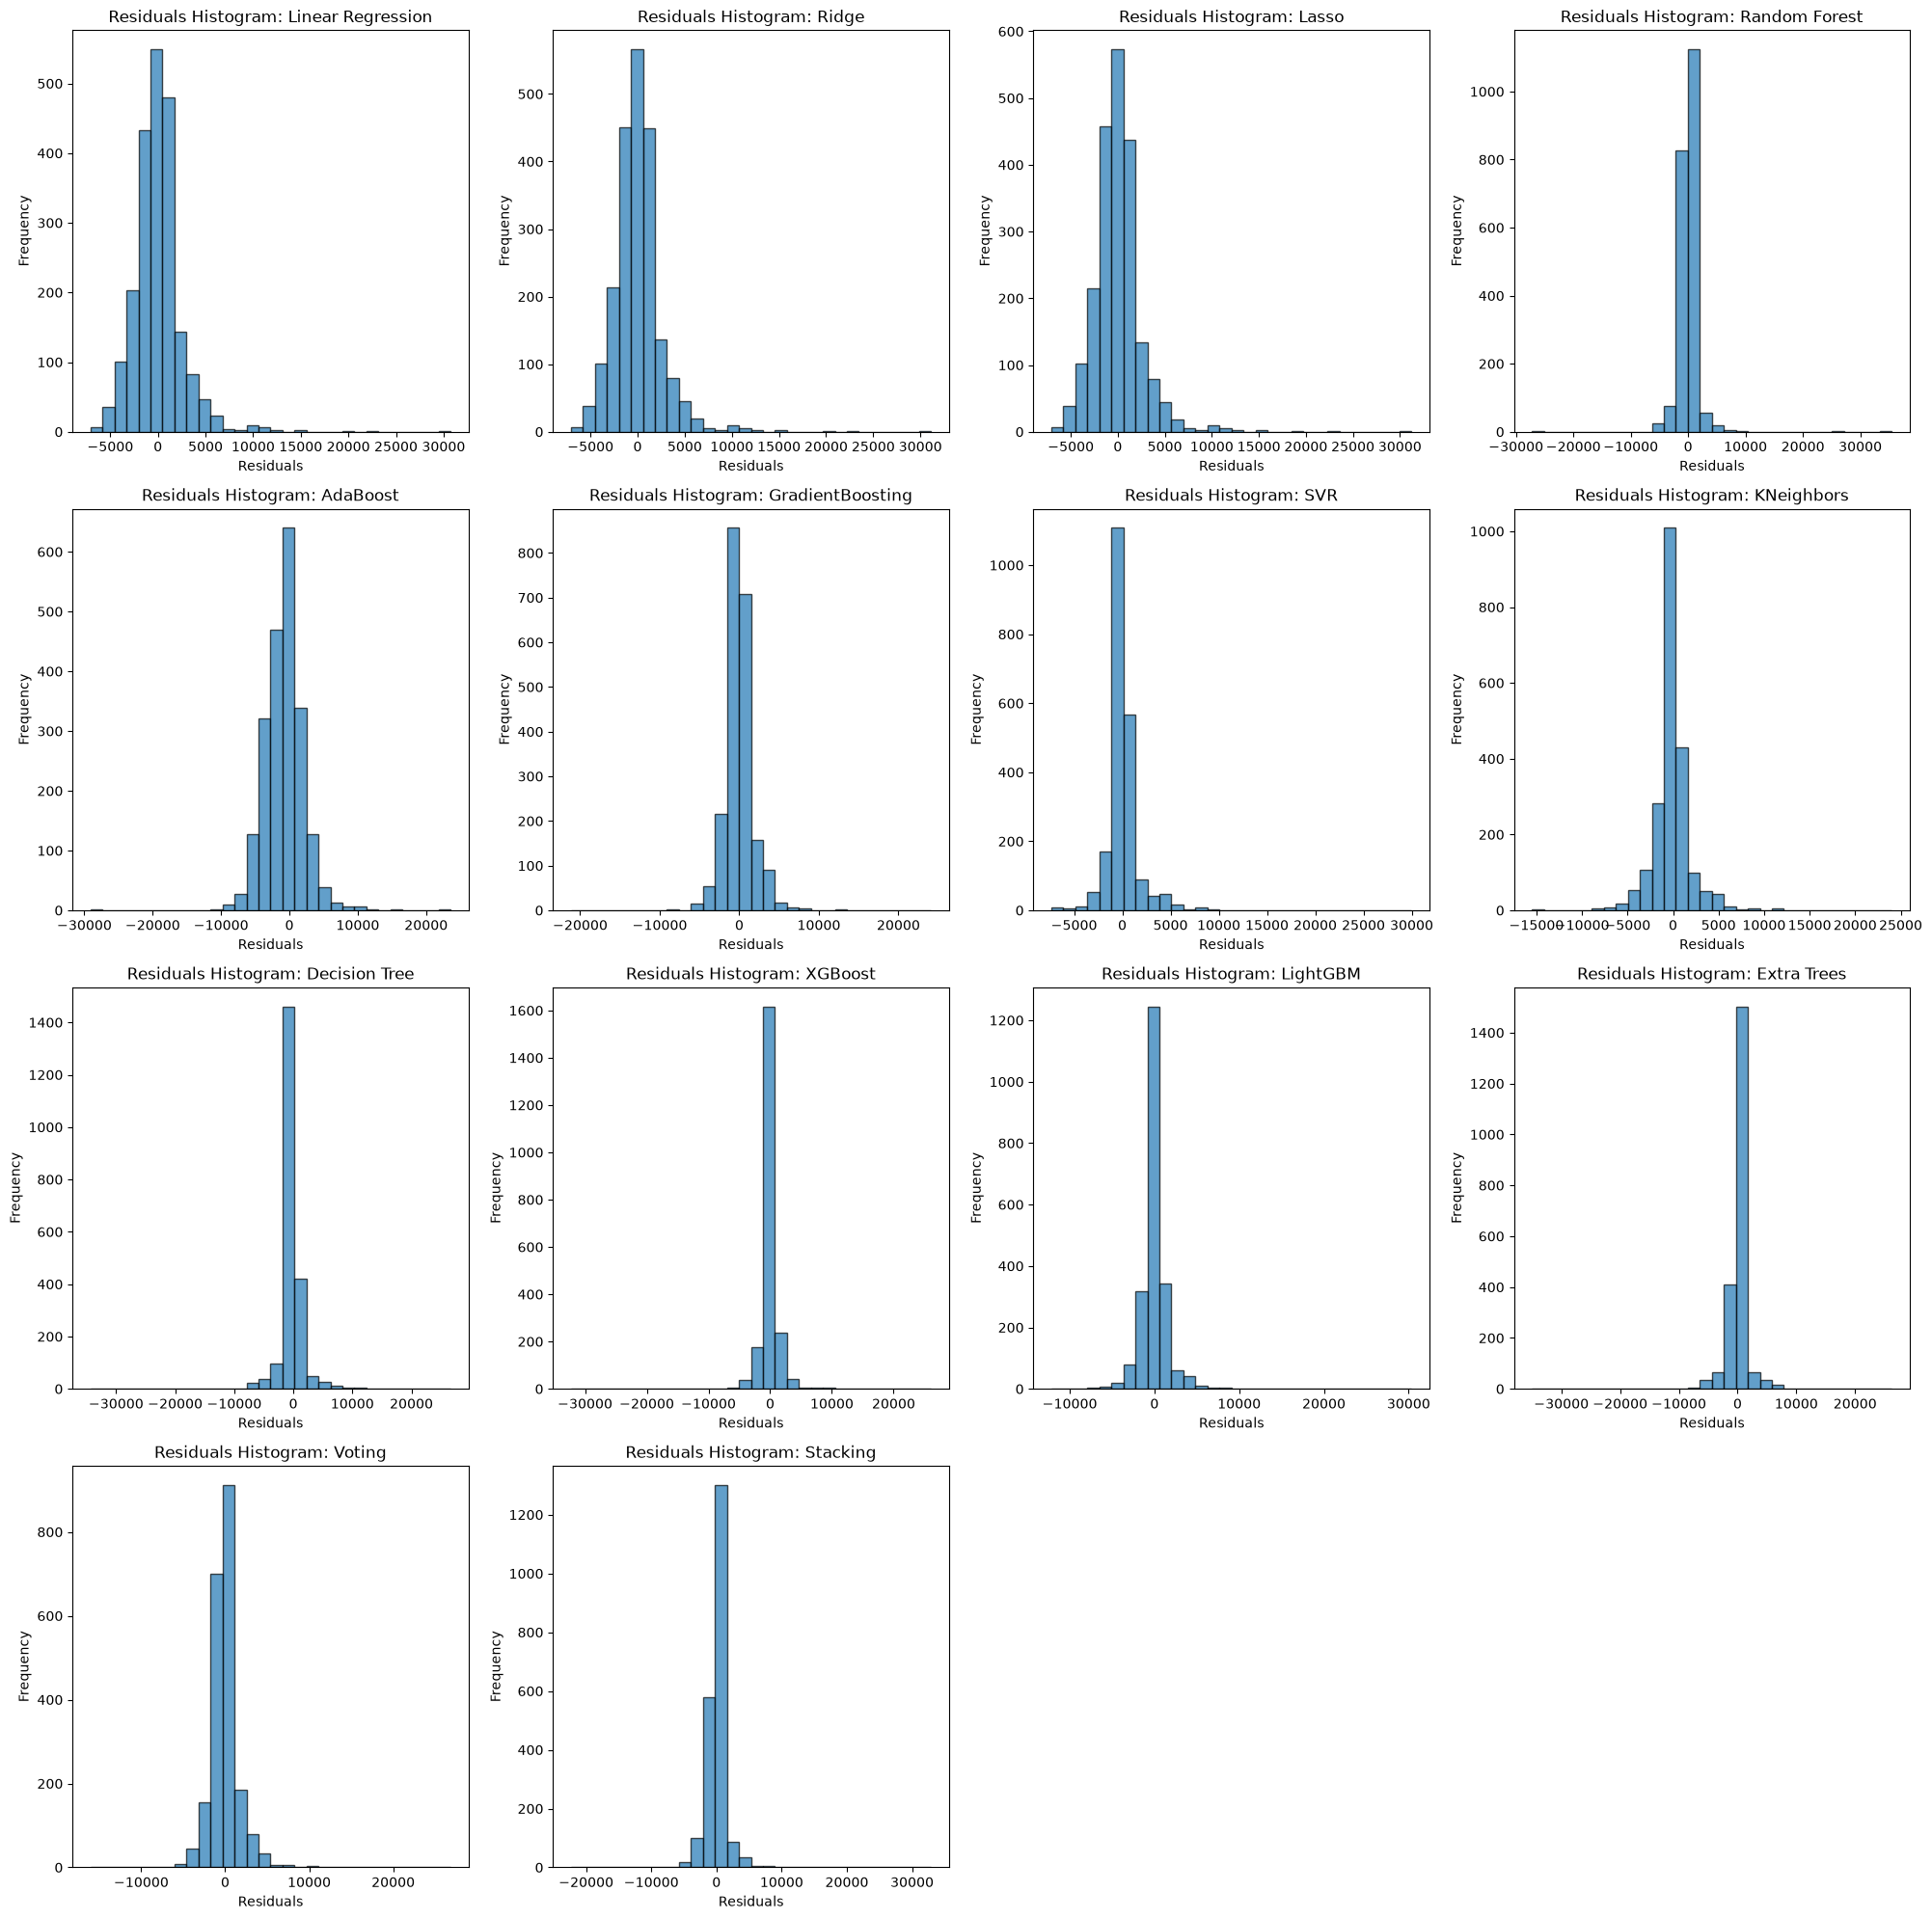

In [99]:
# x an y split (x = input features and y = target features)
x= train_data.drop(columns=['Price'])
y= train_data['Price']

# Identify numerical and categorical features
numerical_features = x.select_dtypes(include=[np.number]).columns.tolist()
categorical_features= x.select_dtypes(include=[object]).columns.tolist()

# One - hot encode categorical features
encoder= OneHotEncoder(sparse_output= False,drop=None)
x_encoded= encoder.fit_transform(x[categorical_features])
x_encoded_df= pd.DataFrame(x_encoded, columns= encoder.get_feature_names_out(categorical_features))

# Combine numerical and encoded categorical features
x_final= pd.concat([x[numerical_features].reset_index(drop= True), x_encoded_df.reset_index(drop= True)], axis=1)

#Train- test split
x_train,x_test,y_train,y_test= train_test_split(x_final,y ,test_size=0.2,random_state=42)

# Standadize numerical features after the train-test split
scaler= StandardScaler()
x_train[numerical_features] = scaler.fit_transform(x_train[numerical_features])
x_test[numerical_features] = scaler.transform(x_test[numerical_features])



# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'Random Forest': RandomForestRegressor(),
    'AdaBoost': AdaBoostRegressor(),
    'GradientBoosting': GradientBoostingRegressor(),
    'SVR': SVR(kernel='rbf',C=10000,epsilon=0.1),
    'KNeighbors': KNeighborsRegressor(),
    'Decision Tree': DecisionTreeRegressor(),
    'XGBoost': XGBRegressor(eval_metric='rmse'),
    'LightGBM': LGBMRegressor(),
    'Extra Trees': ExtraTreesRegressor(),
    'Voting': VotingRegressor(estimators=[
        ('lr', LinearRegression()),  # ye combinations change kiye jaa sakte h aur inhe change karke aur new models k combination mai run kiya ja sakta h
        ('rf', RandomForestRegressor()),
        ('gbr', GradientBoostingRegressor())
    ]),
    'Stacking': StackingRegressor(estimators=[
    ('rf', RandomForestRegressor(n_estimators=350,max_samples=0.5,max_features=0.75,max_depth=15)),
    ('gbdt',GradientBoostingRegressor(n_estimators=100,max_features=0.5)),# ye combinations change kiye jaa sakte h aur inhe change karke aur new models k combination mai run kiya ja sakta
    ])
}

# Train and evaluate models
results = {}

for i, (name, model) in enumerate(tqdm(models.items()), 1):
    start_time = time.time()
    model.fit(x_train, y_train)
    training_time = time.time() - start_time

    start_time = time.time()
    y_pred_train = model.predict(x_train)
    y_pred_test = model.predict(x_test)
    testing_time = time.time() - start_time

    mse_train = mean_squared_error(y_train, y_pred_train)
    rmse_train = np.sqrt(mse_train)
    mae_train = mean_absolute_error(y_train, y_pred_train)
    r2_train = r2_score(y_train, y_pred_train)

    mse_test = mean_squared_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mse_test)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    r2_test = r2_score(y_test, y_pred_test)

    results[name] = {
        'Train Mean Squared Error': mse_train,
        'Train Root Mean Squared Error': rmse_train,
        'Train Mean Absolute Error': mae_train,
        'Train R2 Score': r2_train,
        'Test Mean Squared Error': mse_test,
        'Test Root Mean Squared Error': rmse_test,
        'Test Mean Absolute Error': mae_test,
        'Test R2 Score': r2_test,
        'Training Time (s)': training_time,
        'Testing Time (s)': testing_time
    }

# Display results with exact values
pd.set_option('display.float_format', lambda x: '%.3f' % x)
results_df = pd.DataFrame(results).T
#print(results_df)

# Plot histogram of residuals for each model
plt.figure(figsize=(20, 20))

for i, (name, model) in enumerate(tqdm(models.items()), 1):
    y_pred = model.predict(x_test)
    residuals = y_test - y_pred

    plt.subplot(4, 4, i)
    plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
    plt.xlabel('Residuals')
    plt.ylabel('Frequency')
    plt.title(f'Residuals Histogram: {name}')

plt.tight_layout()
plt.show()



In [100]:
results_df

,Train Mean Squared Error,Train Root Mean Squared Error,Train Mean Absolute Error,Train R2 Score,Test Mean Squared Error,Test Root Mean Squared Error,Test Mean Absolute Error,Test R2 Score,Training Time (s),Testing Time (s)
Linear Regression,7305381.498,2702.847,1755.529,0.655,6741789.561,2596.496,1749.325,0.687,0.012,0.003
Ridge,7306355.329,2703.027,1755.880,0.655,6751677.072,2598.399,1749.720,0.687,0.005,0.004
Lasso,7308937.755,2703.505,1755.198,0.655,6757166.784,2599.455,1748.552,0.687,0.078,0.003
Random Forest,505114.957,710.714,312.398,0.976,2893057.622,1700.899,740.704,0.866,2.178,0.172
AdaBoost,8836478.953,2972.622,2207.297,0.583,8805018.413,2967.325,2167.652,0.592,0.232,0.028
GradientBoosting,4014508.227,2003.624,1220.589,0.811,3723189.047,1929.557,1234.654,0.827,0.802,0.011
SVR,3613271.066,1900.861,769.117,0.829,3224542.911,1795.701,911.293,0.850,18.702,7.150
KNeighbors,3384893.348,1839.808,1002.515,0.840,4359912.023,2088.040,1257.486,0.798,0.003,1.899
Decision Tree,131325.762,362.389,68.081,0.994,3760666.034,1939.244,837.541,0.826,0.039,0.007
XGBoost,781800.188,884.195,545.016,0.963,2772108.000,1664.965,826.833,0.871,0.115,0.013


 71%|███████▏  | 10/14 [00:31<00:12,  3.05s/it]

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000453 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 359
[LightGBM] [Info] Number of data points in the train set: 9079, number of used features: 41
[LightGBM] [Info] Start training from score 9065.887873


100%|██████████| 14/14 [00:01<00:00,  9.33it/s]


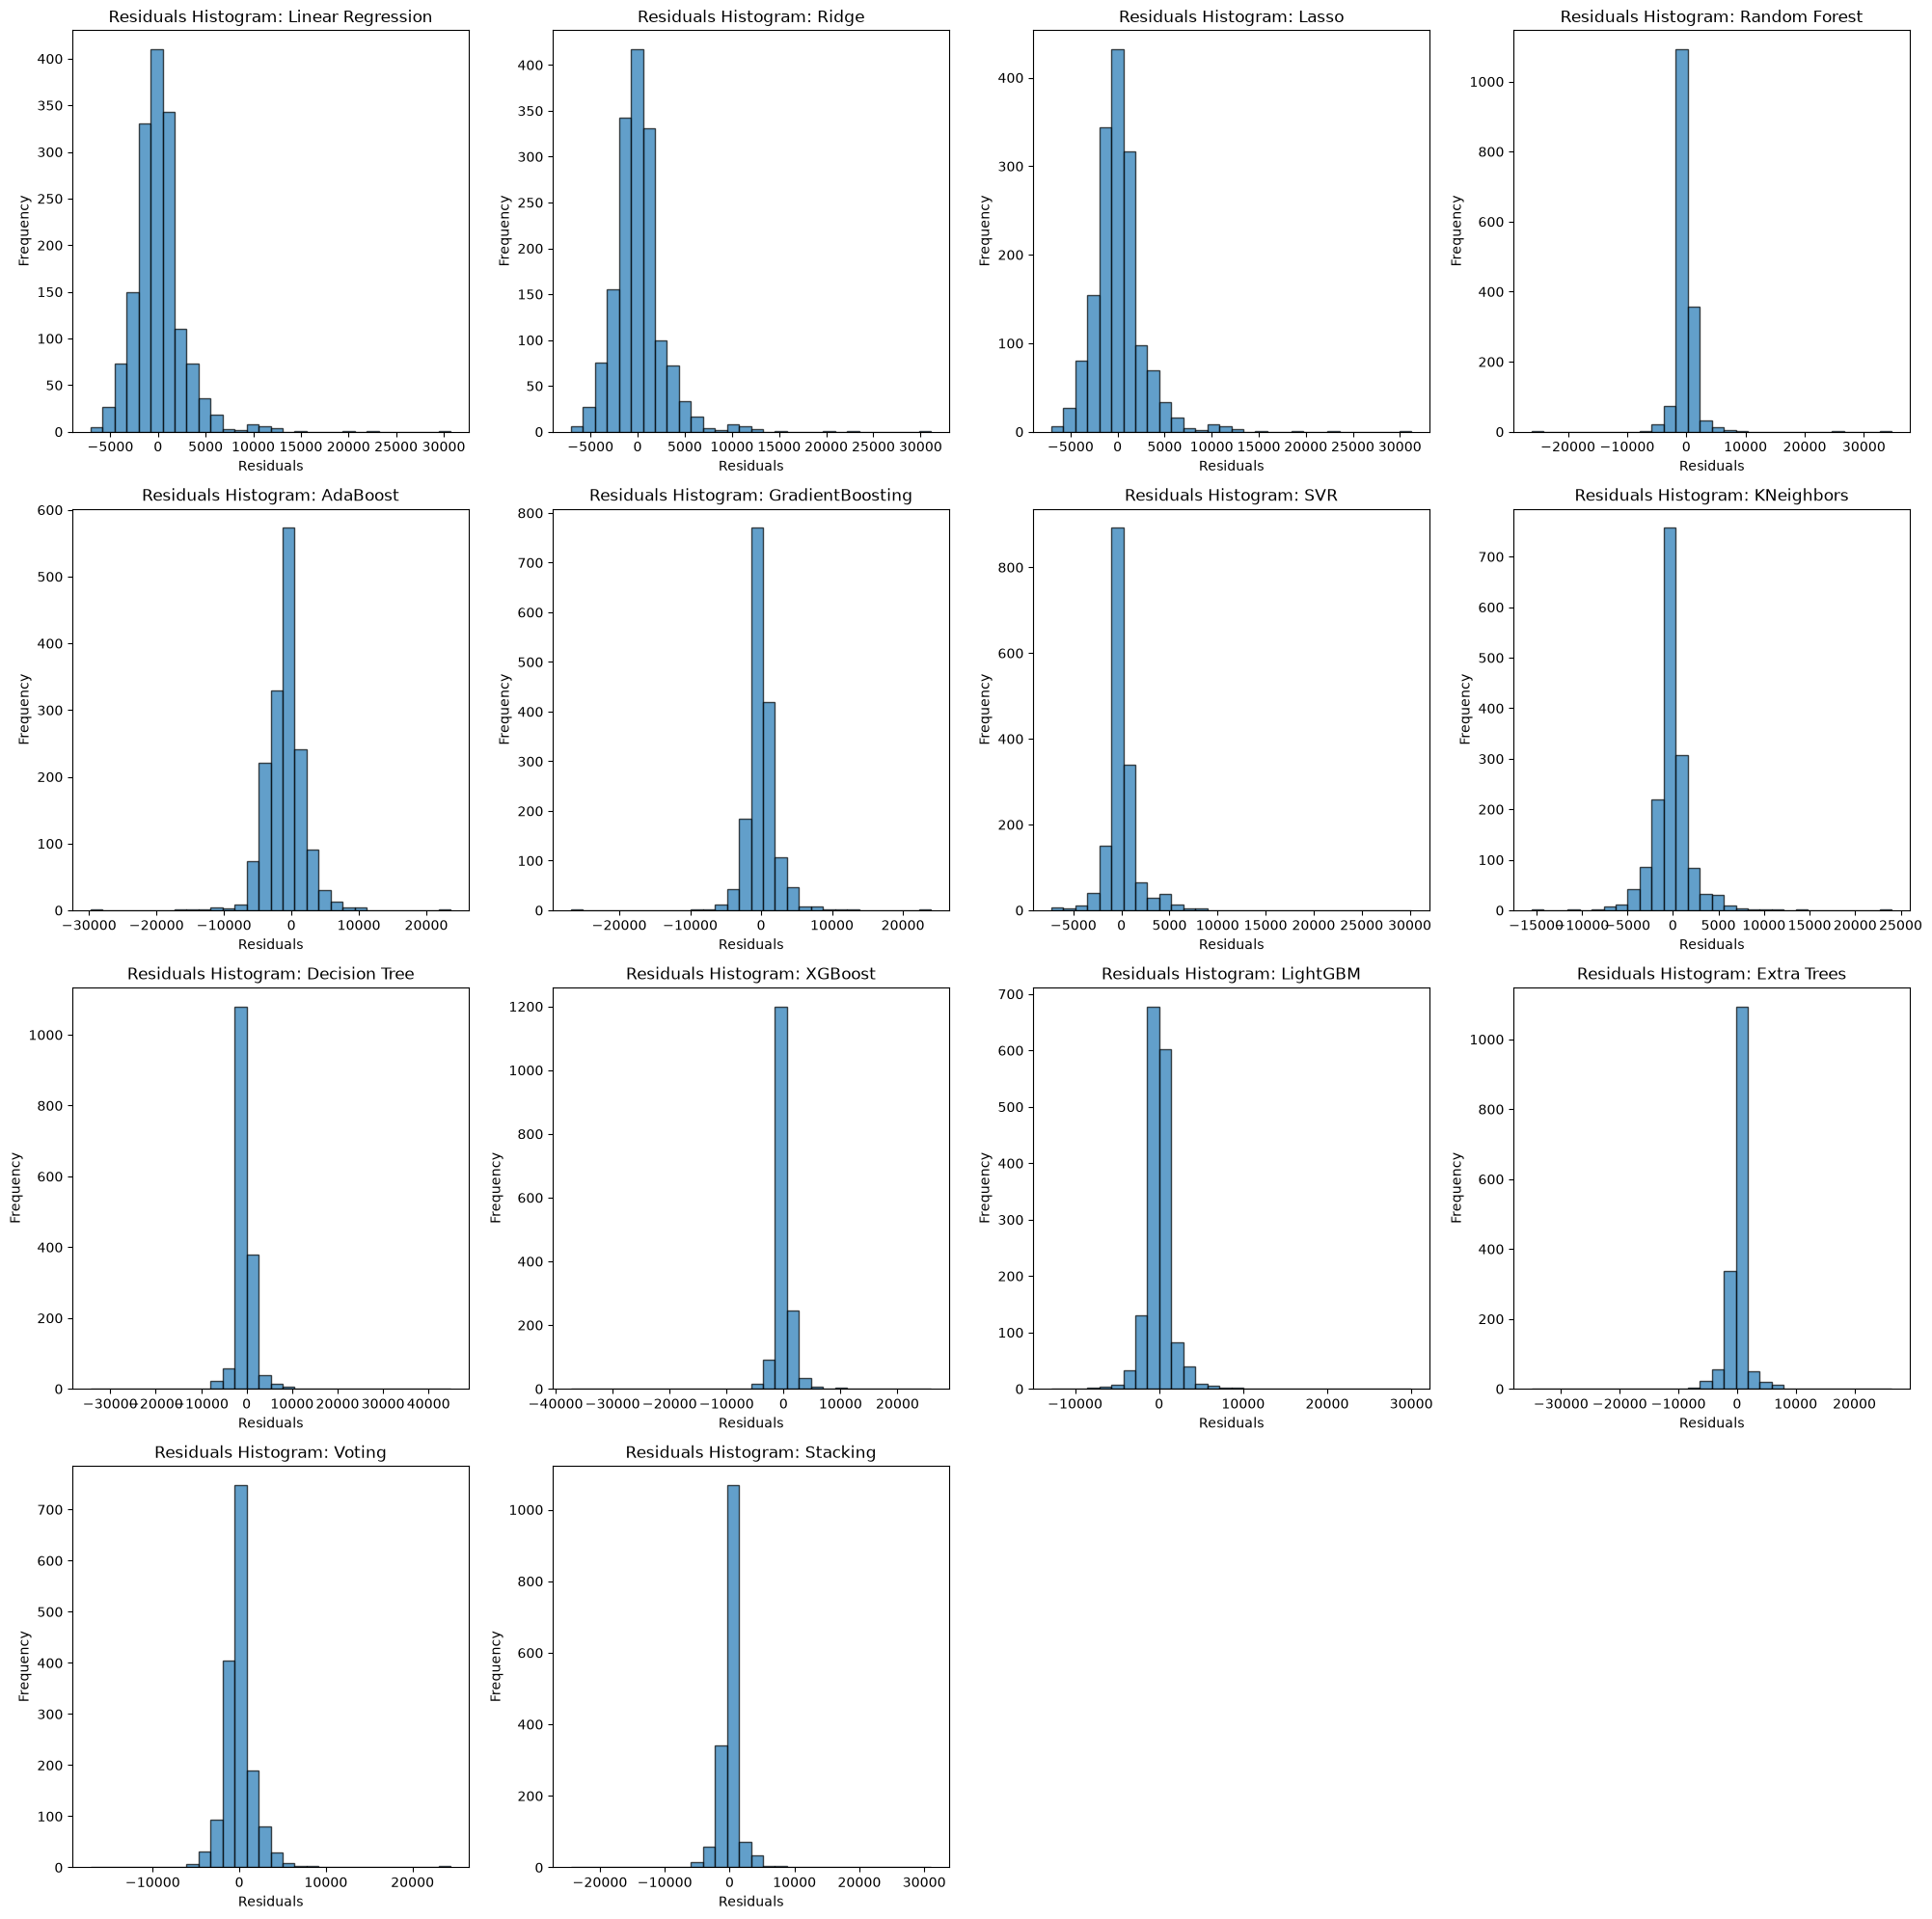

In [101]:
# X and y split (X = input features and y = target feature)
x = train_data.drop(columns=['Price'])
y = train_data['Price']

# Identify numerical and categorical features
numerical_features = x.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = x.select_dtypes(include=[object]).columns.tolist()

# One-hot encode categorical features
encoder = OneHotEncoder(sparse_output= False, drop=None)
x_encoded = encoder.fit_transform(x[categorical_features])
x_encoded_df = pd.DataFrame(x_encoded, columns=encoder.get_feature_names_out(categorical_features))

# Combine numerical and encoded categorical features
x_final = pd.concat([x[numerical_features].reset_index(drop=True), x_encoded_df.reset_index(drop=True)], axis=1)

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(x_final, y, test_size=0.15, random_state=42)

# Standardize numerical features after the train-test split
scaler = StandardScaler()
x_train[numerical_features] = scaler.fit_transform(x_train[numerical_features])
x_test[numerical_features] = scaler.transform(x_test[numerical_features])

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'Random Forest': RandomForestRegressor(),
    'AdaBoost': AdaBoostRegressor(),
    'GradientBoosting': GradientBoostingRegressor(),
    'SVR': SVR(kernel='rbf',C=10000,epsilon=0.1),
    'KNeighbors': KNeighborsRegressor(),
    'Decision Tree': DecisionTreeRegressor(),
    'XGBoost': XGBRegressor(eval_metric='rmse'),
    'LightGBM': LGBMRegressor(),
    'Extra Trees': ExtraTreesRegressor(),
    'Voting': VotingRegressor(estimators=[
        ('lr', LinearRegression()),  # ye combinations change kiye jaa sakte h aur inhe change karke aur new models k combination mai run kiya ja sakta h
        ('rf', RandomForestRegressor()),
        ('gbr', GradientBoostingRegressor())
    ]),
    'Stacking': StackingRegressor(estimators=[
    ('rf', RandomForestRegressor(n_estimators=350,random_state=3,max_samples=0.5,max_features=0.75,max_depth=15)),
    ('gbdt',GradientBoostingRegressor(n_estimators=100,max_features=0.5)),# ye combinations change kiye jaa sakte h aur inhe change karke aur new models k combination mai run kiya ja sakta h
    ('xgb', XGBRegressor(n_estimators=25,learning_rate=0.3,max_depth=5))
    ])
}

# Train and evaluate models
results = {}

for i, (name, model) in enumerate(tqdm(models.items()), 1):
    start_time = time.time()
    model.fit(x_train, y_train)
    training_time = time.time() - start_time

    start_time = time.time()
    y_pred_train = model.predict(x_train)
    y_pred_test = model.predict(x_test)
    testing_time = time.time() - start_time

    mse_train = mean_squared_error(y_train, y_pred_train)
    rmse_train = np.sqrt(mse_train)
    mae_train = mean_absolute_error(y_train, y_pred_train)
    r2_train = r2_score(y_train, y_pred_train)

    mse_test = mean_squared_error(y_test, y_pred_test)
    rmse_test = np.sqrt(mse_test)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    r2_test = r2_score(y_test, y_pred_test)

    results[name] = {
        'Train Mean Squared Error': mse_train,
        'Train Root Mean Squared Error': rmse_train,
        'Train Mean Absolute Error': mae_train,
        'Train R2 Score': r2_train,
        'Test Mean Squared Error': mse_test,
        'Test Root Mean Squared Error': rmse_test,
        'Test Mean Absolute Error': mae_test,
        'Test R2 Score': r2_test,
        'Training Time (s)': training_time,
        'Testing Time (s)': testing_time
    }

# Display results with exact values
pd.set_option('display.float_format', lambda x: '%.3f' % x)
results_df = pd.DataFrame(results).T
#print(results_df)

# Plot histogram of residuals for each model
plt.figure(figsize=(20, 20))

for i, (name, model) in enumerate(tqdm(models.items()), 1):
    y_pred = model.predict(x_test)
    residuals = y_test - y_pred

    plt.subplot(4, 4, i)
    plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
    plt.xlabel('Residuals')
    plt.ylabel('Frequency')
    plt.title(f'Residuals Histogram: {name}')

plt.tight_layout()
plt.show()


In [102]:
results_df

,Train Mean Squared Error,Train Root Mean Squared Error,Train Mean Absolute Error,Train R2 Score,Test Mean Squared Error,Test Root Mean Squared Error,Test Mean Absolute Error,Test R2 Score,Training Time (s),Testing Time (s)
Linear Regression,7158415.380,2675.522,1741.957,0.658,7387899.874,2718.069,1803.920,0.680,0.016,0.005
Ridge,7159305.538,2675.688,1742.241,0.658,7400615.532,2720.407,1804.528,0.679,0.006,0.003
Lasso,7161864.428,2676.166,1741.508,0.658,7407540.834,2721.680,1803.343,0.679,0.083,0.003
Random Forest,499459.742,706.725,308.746,0.976,3267238.380,1807.550,755.022,0.858,2.369,0.161
AdaBoost,9346865.437,3057.264,2205.885,0.554,8672186.081,2944.858,2106.774,0.624,0.255,0.028
GradientBoosting,3938904.202,1984.667,1227.158,0.812,4202407.001,2049.977,1280.738,0.818,0.818,0.010
SVR,3501525.596,1871.236,762.665,0.833,3572807.770,1890.187,941.558,0.845,21.054,6.527
KNeighbors,3303153.766,1817.458,984.757,0.842,4494259.219,2119.967,1263.221,0.805,0.003,0.111
Decision Tree,135778.891,368.482,70.467,0.994,5920342.983,2433.175,894.095,0.744,0.042,0.007
XGBoost,786887.125,887.067,539.529,0.962,3293029.500,1814.671,823.077,0.857,0.100,0.011


# Feature Importance

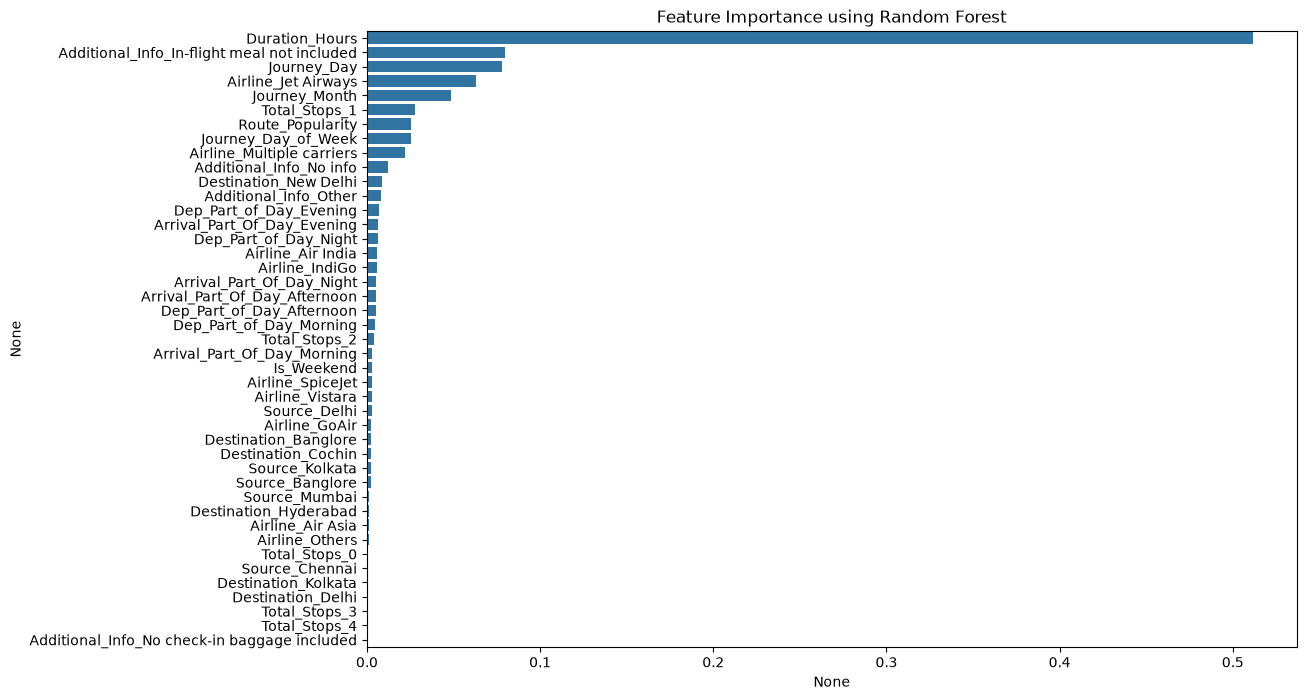

In [103]:
# Train Random Forest
model = RandomForestRegressor()
model.fit(x_train, y_train)

# Get feature importances
feature_importance = pd.Series(model.feature_importances_, index=x_train.columns)
feature_importance.sort_values(ascending=False, inplace=True)

# Plotting feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importance, y=feature_importance.index)
plt.title('Feature Importance using Random Forest')
plt.show()

### Recursive Feature Elimination (RFE)

In [104]:
## top 20 using RFE

In [105]:
from sklearn.feature_selection import RFE

# Perform RFE
rfe = RFE(model, n_features_to_select=20)
rfe.fit(x_train, y_train)

# Selected features
selected_features_rfe = x_train.columns[rfe.support_]
selected_features_rfe

Index(['Journey_Day', 'Journey_Month', 'Journey_Day_of_Week', 'Duration_Hours',
       'Route_Popularity', 'Airline_Air India', 'Airline_IndiGo',
       'Airline_Jet Airways', 'Airline_Multiple carriers',
       'Destination_New Delhi', 'Total_Stops_1',
       'Additional_Info_In-flight meal not included',
       'Additional_Info_No info', 'Additional_Info_Other',
       'Dep_Part_of_Day_Afternoon', 'Dep_Part_of_Day_Evening',
       'Dep_Part_of_Day_Night', 'Arrival_Part_Of_Day_Afternoon',
       'Arrival_Part_Of_Day_Evening', 'Arrival_Part_Of_Day_Night'],
      dtype='str')

In [106]:
### Using Extra Trees Regressor

In [107]:
# Important feature using ExtraTreesRegressor

from sklearn.ensemble import ExtraTreesRegressor
selection = ExtraTreesRegressor()
selection.fit(x_train, y_train)


selection.feature_importances_

array([6.35042015e-02, 5.02293519e-02, 2.38299246e-02, 9.04267896e-03,
       1.17149954e-01, 1.20473759e-02, 7.39744417e-04, 9.28557124e-03,
       1.51782708e-03, 3.43812302e-03, 8.22158646e-02, 2.91333664e-02,
       1.30560717e-03, 1.55043247e-03, 5.52041809e-03, 4.32003712e-03,
       1.33354342e-03, 3.07729395e-03, 1.80984624e-03, 3.02814594e-03,
       1.70048037e-03, 2.80800024e-03, 2.22358056e-04, 3.35264198e-03,
       1.08011962e-03, 1.12892036e-02, 3.50422614e-01, 3.51504398e-02,
       3.58640259e-03, 1.14176322e-03, 4.29365144e-05, 8.33489266e-02,
       3.39930273e-05, 1.61082941e-02, 1.39141667e-02, 5.35235844e-03,
       6.82024842e-03, 7.22804799e-03, 3.85145536e-03, 8.57021812e-03,
       7.69166243e-03, 3.88201191e-03, 8.32234976e-03])

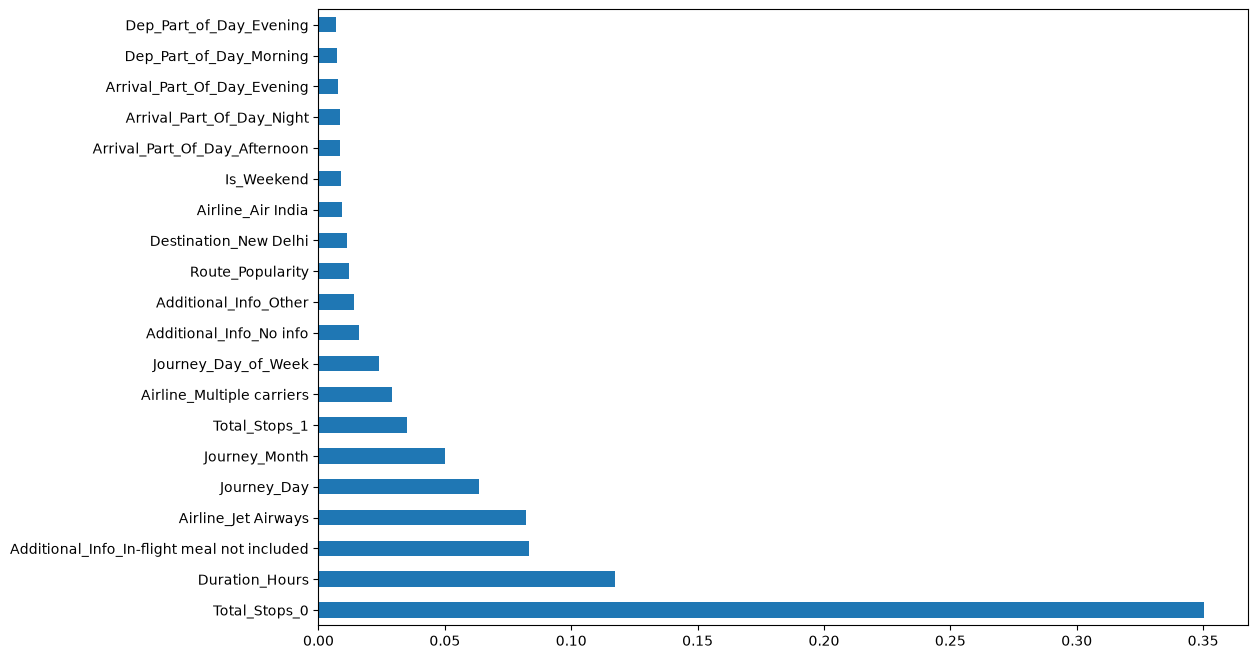

In [108]:
#plot graph of feature importances for better visualization

plt.figure(figsize = (12,8))
feat_importances = pd.Series(selection.feature_importances_, index=x_train.columns)
feat_importances.nlargest(20).plot(kind='barh')
plt.show()


### Using Column Transformer and Pipeline

In [109]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score,mean_absolute_error

In [110]:
#train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.15,random_state=2)

**X and y break of input and output features**

In [111]:
x = train_data.drop(columns=['Price'])
y = np.log(train_data['Price']) #natural logarithm of the price

**Train test split with test size = 15% and train size = 85%**

In [112]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.15,random_state=2)

In [113]:
x_train.shape

(9079, 13)

In [114]:
x_test

,Airline,Source,Destination,Total_Stops,Additional_Info,Journey_Day,Journey_Month,Journey_Day_of_Week,Is_Weekend,Dep_Part_of_Day,Arrival_Part_Of_Day,Duration_Hours,Route_Popularity
8838,Air India,Delhi,Cochin,2,No info,12,6,2,0,Afternoon,Morning,19.667,4536
6183,Jet Airways,Banglore,New Delhi,1,No info,6,3,2,0,Afternoon,Evening,6.250,932
4095,Jet Airways,Mumbai,Hyderabad,0,No info,21,3,3,0,Morning,Morning,1.417,697
230,Air India,Kolkata,Banglore,1,No info,24,3,6,1,Afternoon,Evening,25.667,2871
5712,Jet Airways,Delhi,Cochin,2,In-flight meal not included,1,6,5,1,Evening,Night,8.417,4536
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5559,Jet Airways,Delhi,Cochin,2,In-flight meal not included,27,6,3,0,Morning,Evening,9.333,4536
9275,Air Asia,Kolkata,Banglore,1,No info,9,5,3,0,Evening,Night,3.583,2871
2654,Jet Airways,Delhi,Cochin,2,In-flight meal not included,6,3,2,0,Morning,Evening,38.250,4536
3718,Jet Airways,Banglore,Delhi,0,No info,12,5,6,1,Evening,Night,3.083,1265


### Necessary Imports

In [115]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score,mean_absolute_error
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,AdaBoostRegressor,ExtraTreesRegressor
from sklearn.svm import SVR

In [116]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

# Sample data preparation (replace with your actual data)
# X_train, X_test, y_train, y_test should already be defined

# Define the steps in the pipeline
step1 = ColumnTransformer(transformers=[
    ('col_tnf', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'), [0, 1, 2,4,9,10])
], remainder='passthrough')

step2 = RandomForestRegressor(n_estimators=100,
                              random_state=3,
                              max_samples=0.5,
                              max_features=0.75,
                              max_depth=15)

pipe = Pipeline([
    ('step1', step1),
    ('step2', step2)
])

# Fit the pipeline on the training data
pipe.fit(x_train, y_train)

# Predict on the test data
y_pred = pipe.predict(x_test)

# Print evaluation metrics
print('R2 score:', r2_score(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))


R2 score: 0.9145661653150825
MAE: 0.08893868591074984


### Exporting the Model

In [117]:
import pickle

pickle.dump(train_data,open('train_data.pkl','wb'))
pickle.dump(pipe,open('pipe.pkl','wb'))

In [118]:
train_data

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Journey_Day,Journey_Month,Journey_Day_of_Week,Is_Weekend,Dep_Part_of_Day,Arrival_Part_Of_Day,Duration_Hours,Route_Popularity
0,IndiGo,Banglore,New Delhi,0,No info,3897,24,3,6,1,Night,Night,2.833,932
1,Air India,Kolkata,Banglore,2,No info,7662,1,5,2,0,Morning,Afternoon,7.417,2871
2,Jet Airways,Delhi,Cochin,2,No info,13882,9,6,6,1,Morning,Night,19.000,4536
3,IndiGo,Kolkata,Banglore,1,No info,6218,12,5,6,1,Evening,Night,5.417,2871
4,IndiGo,Banglore,New Delhi,1,No info,13302,1,3,4,0,Afternoon,Night,4.750,932
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,0,No info,4107,9,4,1,0,Evening,Night,2.500,2871
10679,Air India,Kolkata,Banglore,0,No info,4145,27,4,5,1,Evening,Night,2.583,2871
10680,Jet Airways,Banglore,Delhi,0,No info,7229,27,4,5,1,Morning,Morning,3.000,1265
10681,Vistara,Banglore,New Delhi,0,No info,12648,1,3,4,0,Morning,Afternoon,2.667,932
